# TFG ANALYTICS

### Carmen Humanes

In [50]:
# Lo primero es importar las librerías que necesitamos
# Básicas
# Básicas
import pandas as pd
import numpy as np
import csv
import re

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Preprocesamiento y modelización (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

# Tratamiento del desbalanceo (imbalanced-learn)
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

# Interpretabilidad
import shap

In [51]:
#Limpio el csv original para eliminar  líneas vacías y registros con pocos campos

input_file = r"C:\Users\carme\OneDrive\Documentos\TFGs\TFG Analytics\Crash_Reporting_-_Drivers_Data_original.csv"
output_file = "Dataset_limpio.csv"

with open(input_file, "r", encoding="utf-8") as myfile:
    lines = myfile.readlines()
    
print(len(lines))

print(lines[4])

lines2 =[]

for elemento in lines :
    if len(elemento) >2  : # con esto quito lineas vacías
        lines2.append (elemento)
print(len(lines2)) 

lines3 =[]

for elemento2 in lines2 :
    
    campos = elemento2.split(",")
    len(campos)
    if (len(campos)) >2  : # con esto quito lineas con pocos campos
        lines3.append (elemento2)
print(len(lines3))

with open(output_file, "w", encoding="utf-8") as myfile2:
    myfile2.writelines(lines3)


205589
"MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,,,,,,Front to Rear,Clear,Dry,Daylight,Flashing Traffic Control Signal,""Not Suspect of Alcohol Use, Not Suspect of Drug Use"",,AE9A3389-3486-4199-B8F6-015D7D2E1139,Yes,No Apparent Injury,Followed Too Closely,""Manually Operating (dialing, playing game, etc.)"",MD,AAEB6B5A-30B2-47D3-BF59-7F14D0A5BCAD,Disabling,Twelve O Clock,Van - Passenger (&lt";"9 Seats),Slowing or Stopping,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.20793083,-77.1414795,""(39.20793083, -77.1414795)"""

205468
205103


In [52]:
#Quito las dobles comillas, el principal error de mi dataset

input_file = r"Dataset_limpio.csv"
fixed_file = "Crash_Reporting_fixed.csv"

with open(input_file, "r", encoding="utf-8", errors="replace") as infile, \
     open(fixed_file, "w", encoding="utf-8") as outfile:
    
    for line in infile:   # sustituyo ""texto"" por "texto"
        line = line.replace('""', '"')
        outfile.write(line)

In [53]:
# En este paso quitamos las comillas que envuelven a cada registro, ya que me di cuenta de que todos los registros empezaban y terminaban por comillas.
input_file = "Crash_Reporting_fixed.csv"
fixed_file = "Dataset_final.csv"

with open(input_file, "r", encoding="utf-8", errors="replace") as infile, \
     open(fixed_file, "w", encoding="utf-8") as outfile:
    
    for line in infile:
        line = line.strip()

        # quitamos ; final si existe
        if line.endswith(";"):
            line = line[:-1]

        # quitamos comillas externas SOLO si envuelven toda la línea
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]

        outfile.write(line + "\n")


In [54]:
#Miro las variables que al visualizar los datos parecía que daban problemas, pero al visualizar aquí vemos que están bien

data = pd.read_csv("Dataset_final.csv",sep=",",engine="python",nrows=10)

data[["Driver Substance Abuse",
    "Non-Motorist Substance Abuse",
    "Person ID"]]

,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID
0,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,BB3CB0F3-5A89-45FB-9516-48DDDB92B0A9
1,"Unknown, Unknown",NaN,9B84E695-215A-447E-8AA6-D3958187BBCA
2,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,1D28ADF4-0DB2-4CBC-BDB0-1C1F5E7CF955
3,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,AE9A3389-3486-4199-B8F6-015D7D2E1139
4,"Unknown, Unknown",NaN,3B4FB53F-9543-48EA-8C28-14AC093FBC36
5,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",391A0858-066B-41A3-926D-B43D84A96A07
6,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",BE379E46-1E1A-4D8E-964D-9CAEEE9B7DCB
7,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,297E1685-92CE-48C4-BEB5-866F63B3F195
8,"Unknown, Unknown",NaN,31489D44-D716-4916-9789-ED4EAB271635
9,"Not Suspect of Alcohol Use, Not Suspect of Dru...",NaN,6A5D1587-F266-4EC7-B635-12DB91ACE089


In [55]:
#Igualmente, si trato de cargar todo el dataset me pone que algún registro tiene error
#Por esto, pongo on_bad_lines y cargamos el dataset.

data = pd.read_csv("Dataset_final.csv",sep=",",engine="python",on_bad_lines="skip")

data.shape

(203890, 39)

In [56]:
#Visualizamos las primeras 20 filas del dataset para ver que ya está bien
data.head(20)

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Vehicle Going Dir,Speed Limit,Driverless Vehicle,Parked Vehicle,Vehicle Year,Vehicle Make,Vehicle Model,Latitude,Longitude,Location
0,MCP3126006X,250037402,MONTGOMERY,Injury Crash,08/21/2025 05:21:00 PM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Northbound,40,No,No,2013,KIA,SOUL,39.219796,-77.257416,"(39.219796, -77.25741635)"
1,MCP2349001B,250037516,MONTGOMERY,Property Damage Crash,08/22/2025 10:44:00 AM,Interstate (State),EISENHOWER MEMORIAL HWY,NaN,NaN,NaN,...,Northbound,55,No,No,0,NaN,NaN,39.180181,-77.250657,"(39.18018079, -77.25065714)"
2,MCP296500BC,250033157,MONTGOMERY,Property Damage Crash,07/25/2025 11:55:00 AM,Bicycle Route,NaN,NEW HAMPSHIRE AVE (SB/L) NORBECK RD (WB/L) SPE...,NaN,NaN,...,Westbound,40,No,No,2023,LEXUS,RX,39.121219,-76.988905,"(39.12121898, -76.98890509)"
3,MCP2159003K,250037509,MONTGOMERY,Property Damage Crash,08/22/2025 10:36:00 AM,Maryland (State) Route,NaN,NaN,NaN,NaN,...,Southbound,30,No,No,2003,TOYOTA,SIENNA,39.207931,-77.141480,"(39.20793083, -77.1414795)"
4,MCP312900D6,250034573,MONTGOMERY,Property Damage Crash,08/03/2025 02:10:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 2741 UNI...,NaN,...,Not On Roadway,0,No,No,2023,SUBARU,IMPREZA,39.039662,-77.057238,"(39.03966248, -77.05723843)"
5,MCP284600BN,250037004,MONTGOMERY,Injury Crash,08/19/2025 09:50:00 AM,County Route,GRAND PRE RD,NaN,NaN,NaN,...,Northbound,25,No,No,2016,MAZDA,CX-5,39.092734,-77.076470,"(39.09273383, -77.07647)"
6,MCP2968005X,250037708,MONTGOMERY,Injury Crash,08/23/2025 11:50:00 AM,Maryland (State) Route,ROCKVILLE PIKE (SB/L),NaN,NaN,NaN,...,NaN,0,No,No,2025,MAZDA,CX-90,39.058466,-77.121265,"(39.05846583, -77.12126533)"
7,MCP3168008H,250037462,MONTGOMERY,Property Damage Crash,08/21/2025 10:45:00 PM,Bicycle Route,NaN,NaN,NaN,NaN,...,Westbound,25,No,No,2021,TOYOTA,VENZA,39.056209,-77.119080,"(39.0562091, -77.11907977)"
8,MCP3068006J,250037227,MONTGOMERY,Property Damage Crash,08/20/2025 03:15:00 PM,Other Public Roadway,ALLEY,NaN,NaN,NaN,...,Northbound,10,No,No,2022,FORD,F-650,38.988083,-77.094093,"(38.98808273, -77.09409312)"
9,MCP137801DC,250034694,MONTGOMERY,Property Damage Crash,08/04/2025 03:47:00 PM,Maryland (State) Route,GEORGIA AVE (SB/L),OLNEY LAYTONSVILLE RD,NaN,NaN,...,Eastbound,35,No,No,2018,FORD,TRANSIT CONNECT,39.153220,-77.067015,"(39.15322038, -77.06701504)"


## Carga del conjunto de datos

Ahora quiero empezar a tratar los valores nulos de mi dataset

In [57]:
data.isna().values.any()

np.True_

In [58]:
#Como hemos visto que sí que hay valores nulos, ahora vamos a ver cúantos hay para cada variable
(data.isna().mean() * 100).sort_values(ascending=False)

Non-Motorist Substance Abuse     97.317671
Related Non-Motorist             96.755604
Off-Road Description             90.725391
Municipality                     90.619452
Circumstance                     80.739124
Cross-Street Name                17.713473
Driver Substance Abuse           15.357791
Traffic Control                  13.939870
Surface Condition                11.398793
Road Name                        11.300701
Route Type                        9.845014
Drivers License State             6.658983
Weather                           6.547158
Vehicle Going Dir                 4.046299
Vehicle Body Type                 1.505714
Driver Distracted By              1.120212
Injury Severity                   1.037324
Parked Vehicle                    0.748443
Vehicle Movement                  0.711168
Light                             0.708225
Vehicle Model                     0.461523
Vehicle Make                      0.440924
Collision Type                    0.286919
Vehicle Dam

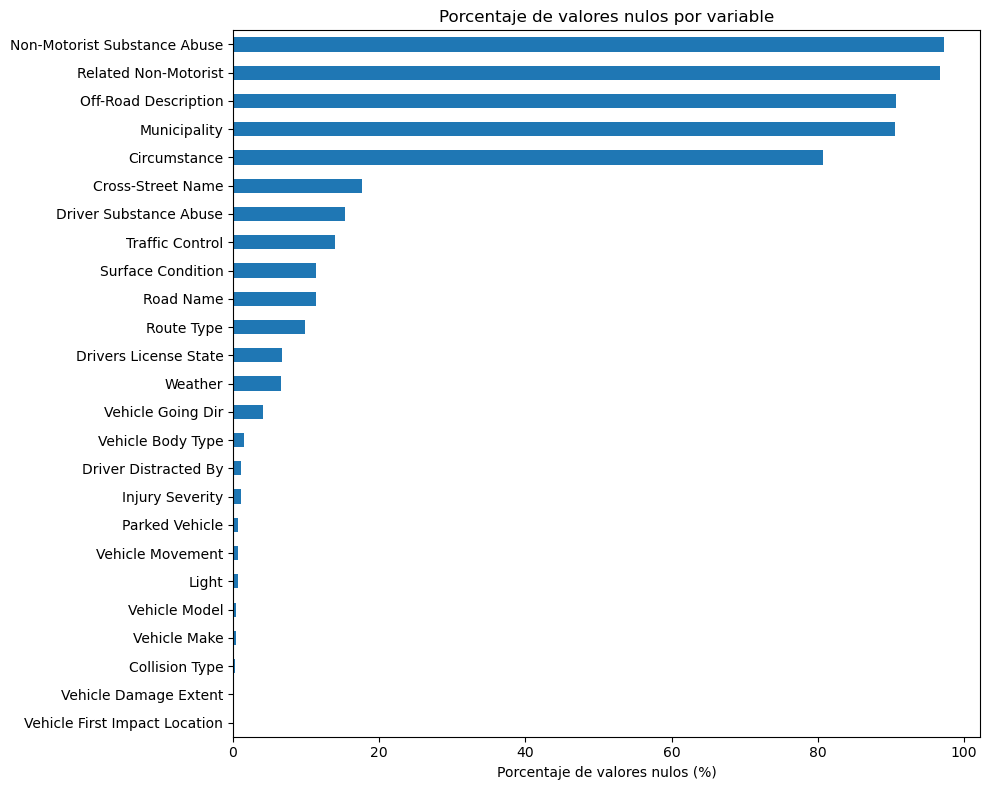

In [59]:
# Calcular porcentaje de NAs
na_percentage = (data.isna().mean() * 100)
na_percentage = na_percentage[na_percentage > 0].sort_values()

plt.figure(figsize=(10,8))
na_percentage.plot(kind='barh')

plt.xlabel('Porcentaje de valores nulos (%)')
plt.title('Porcentaje de valores nulos por variable')
plt.tight_layout()
plt.show()

In [60]:
#Voy a quitar algunas variables que tienen muchos NAs. 
#La variable 'Circumstance' todavía no la voy a quitar porque creo que puede ser interesante. Si veo que luego no me hace falta, ya la quitaré

In [61]:
data[['Circumstance']].head(20)

,Circumstance
0,Followed Too Closely
1,NaN
2,NaN
3,Followed Too Closely
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,Followed Too Closely


In [62]:
#Esta variable la borraré, miro por si acaso
data['Municipality'].unique()

array([nan, 'KENSINGTON', 'ROCKVILLE', 'GAITHERSBURG', 'TAKOMA PARK',
       'FRIENDSHIP HEIGHTS', 'NORTH CHEVY CHASE', 'CHEVY CHASE #3',
       'CHEVY CHASE VIEW', 'CHEVY CHASE #4', 'SOMERSET', 'GARRETT PARK',
       'POOLESVILLE', 'WASHINGTON GROVE', 'CHEVY CHASE VILLAGE',
       'CHEVY CHASE #5', 'GLEN ECHO', 'DRUMMOND', 'BROOKEVILLE',
       'LAYTONSVILLE', 'MATINS ADDITION'], dtype=object)

In [63]:
data['Related Non-Motorist'].value_counts(dropna=False)

Related Non-Motorist
NaN                                                                                       197275
PEDESTRIAN                                                                                  3876
BICYCLIST                                                                                   1169
Pedestrian                                                                                   784
OTHER                                                                                        246
Cyclist (non-electric)                                                                       196
OTHER CONVEYANCE                                                                              84
Scooter (electric)                                                                            62
Cyclist (Electric)                                                                            54
MACHINE OPERATOR/RIDER                                                                        39
OTHER PED

In [64]:
# Quiero hacer una variable binaria, en la que 1 será que si que hay algún no-motorista implicado y 0 si no hay. Convierte Na en 0 y cualquier otra cosa en 1
data['Related Non-Motorist'] = data['Related Non-Motorist'].str.upper().str.strip()  #pongo todas en mayusculas
data['NonMotorist_Involved'] = data['Related Non-Motorist'].notna().astype(int)
data[['NonMotorist_Involved']].head(20)

,NonMotorist_Involved
0,0
1,0
2,0
3,0
4,0
5,1
6,1
7,0
8,0
9,0


In [65]:
data = data.drop(columns=['Related Non-Motorist'])

In [66]:
#Ya tengo la variable binaria creada que me dice si hay algun peatón/ciclista involucrado
data.shape

(203890, 39)

In [67]:
#Voy a mirar la variable Non-Motorist Substance-Abuse
data["Non-Motorist Substance Abuse"].unique()

array([nan, 'Not Suspect of Alcohol Use, Not Suspect of Drug Use',
       'Unknown, Unknown',
       'Not Suspect of Alcohol Use, Not Suspect of Drug Use, Not Suspect of Alcohol Use, Not Suspect of Drug Use, Not Suspect of Alcohol Use, Not Suspect of Drug Use',
       'Suspect of Alcohol Use, Unknown',
       'Suspect of Alcohol Use, Suspect of Drug Use', 'NONE DETECTED',
       'ALCOHOL PRESENT', 'ALCOHOL CONTRIBUTED',
       'ILLEGAL DRUG CONTRIBUTED', 'UNKNOWN', 'N/A, NONE DETECTED',
       'ALCOHOL CONTRIBUTED, ALCOHOL PRESENT',
       'COMBINED SUBSTANCE PRESENT', 'ILLEGAL DRUG PRESENT', 'OTHER',
       'NONE DETECTED, UNKNOWN', 'N/A, UNKNOWN', 'MEDICATION PRESENT',
       'COMBINATION CONTRIBUTED', 'ALCOHOL PRESENT, NONE DETECTED',
       'Not Suspect of Alcohol Use, Suspect of Drug Use',
       'Suspect of Alcohol Use, Not Suspect of Drug Use',
       'Not Suspect of Alcohol Use, Not Suspect of Drug Use, Not Suspect of Alcohol Use, Not Suspect of Drug Use',
       'Not Suspect o

In [68]:
data["Non-Motorist Substance Abuse"].value_counts(dropna=False)

Non-Motorist Substance Abuse
NaN                                                                                                                                                              198421
NONE DETECTED                                                                                                                                                      3863
Not Suspect of Alcohol Use, Not Suspect of Drug Use                                                                                                                 991
UNKNOWN                                                                                                                                                             222
ALCOHOL PRESENT                                                                                                                                                     145
Unknown, Unknown                                                                                                                   

In [69]:
#Como tengo la variable binaria de si hay un peaton implicado o no, usaré la variable Non-Motorist Substance Abuse para ver si estaba bajo 
#los efectos de alguna sustancia, a pesar de su alto nivel de NaN
#Haremos una variable binaria, con 1 para los valores que sí que indiquen que puede estar bajo alguna sustancia, y 0 con ninguna sustancia. 

In [70]:
#Podría haber separado por alcohol y drogas, pero como los valores son tan bajos, he decidido que no es representativo asi que 
#prefiero mantener 1 como abuso de cualquier sustancia

In [71]:
data[["Non-Motorist Substance Abuse"]].head(10)

,Non-Motorist Substance Abuse
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
6,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
7,NaN
8,NaN
9,NaN


In [72]:
data[["Driver Substance Abuse"]].head(10)

,Driver Substance Abuse
0,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
1,"Unknown, Unknown"
2,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
3,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
4,"Unknown, Unknown"
5,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
6,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
7,"Not Suspect of Alcohol Use, Not Suspect of Dru..."
8,"Unknown, Unknown"
9,"Not Suspect of Alcohol Use, Not Suspect of Dru..."


In [73]:
#Voy a aprovechar y a limpiar también Driver Substance Abuse, ya que es muy parecida.
#Hacemos una funcion que me ayude a limpiar estas variables y a volverlas binarias si hay algún indicio de que abusaba de sustancias

In [74]:
# Función para crear variable binaria de abuso de sustancias
def substance_abuse_binary(series):
    # Limpiar texto
    clean = series.fillna('').str.upper().str.strip()

    # Lista de valores positivos
    positive_values = {
        'SUSPECT OF ALCOHOL USE',
        'SUSPECT OF DRUG USE',
        'ALCOHOL PRESENT',
        'ALCOHOL CONTRIBUTED',
        'ILLEGAL DRUG PRESENT',
        'ILLEGAL DRUG CONTRIBUTED',
        'MEDICATION PRESENT',
        'MEDICATION CONTRIBUTED',
        'COMBINED SUBSTANCE PRESENT',
        'COMBINATION CONTRIBUTED'
    }

    # Crear binaria: 1 si alguna parte separada por coma está en positivos
    return clean.apply(
        lambda x: int(
            any(part.strip() in positive_values for part in x.split(','))
        )
    )

# 1) Driver
data['Driver_Substance_Abuse'] = substance_abuse_binary(data['Driver Substance Abuse'])

# 2) Non-motorist
data['NM_Substance_Abuse'] = substance_abuse_binary(data['Non-Motorist Substance Abuse'])

# 3) Coherencia lógica: si no hay non-motorist implicado, entonces 0
data.loc[data['NonMotorist_Involved'] == 0, 'NM_Substance_Abuse'] = 0

In [75]:
#Nos aseguramos de que están limpias
data[["NM_Substance_Abuse"]].head(10)

,NM_Substance_Abuse
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [76]:
data[["Driver_Substance_Abuse"]].head(10)

,Driver_Substance_Abuse
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [77]:
data.shape

(203890, 41)

In [78]:
data = data.drop(columns=['Driver Substance Abuse','Non-Motorist Substance Abuse'
])

In [79]:
#Ya he limpiado esta variable también y el dataset vuelve a tener sus 39 variables
data.shape

(203890, 39)

In [80]:
#Voy a quitar las variables Off-Road description y Municipality porque tienen un porcentaje muy alto de Nas y creo que no me van a ser utiles
data=data.drop(["Off-Road Description","Municipality"],axis=1)

In [81]:
list(data.columns)

['Report Number',
 'Local Case Number',
 'Agency Name',
 'ACRS Report Type',
 'Crash Date/Time',
 'Route Type',
 'Road Name',
 'Cross-Street Name',
 'Collision Type',
 'Weather',
 'Surface Condition',
 'Light',
 'Traffic Control',
 'Person ID',
 'Driver At Fault',
 'Injury Severity',
 'Circumstance',
 'Driver Distracted By',
 'Drivers License State',
 'Vehicle ID',
 'Vehicle Damage Extent',
 'Vehicle First Impact Location',
 'Vehicle Body Type',
 'Vehicle Movement',
 'Vehicle Going Dir',
 'Speed Limit',
 'Driverless Vehicle',
 'Parked Vehicle',
 'Vehicle Year',
 'Vehicle Make',
 'Vehicle Model',
 'Latitude',
 'Longitude',
 'Location',
 'NonMotorist_Involved',
 'Driver_Substance_Abuse',
 'NM_Substance_Abuse']

In [82]:
# Me he dado cuenta de que casi ninguna variable está limpia del todo, ya que tienen valores en mayusculas, otros en minusculas...
# Casi todas las variables tienen valores muy parecidos, omo 'Daylight' o 'DAYLIGHT', así que las pongo todas en mayusculas


In [83]:
data['Weather'].value_counts(normalize=True)

Weather
CLEAR                                0.612729
Clear                                0.130848
RAINING                              0.108108
CLOUDY                               0.090747
Rain                                 0.017665
Cloudy                               0.014863
SNOW                                 0.007568
UNKNOWN                              0.003637
FOGGY                                0.003548
WINTRY MIX                           0.002052
OTHER                                0.001942
Snow                                 0.001412
SLEET                                0.001144
Unknown                              0.001107
SEVERE WINDS                         0.000808
BLOWING SNOW                         0.000604
Fog, Smog, Smoke                     0.000336
Blowing Snow                         0.000336
Freezing Rain Or Freezing Drizzle    0.000278
Severe Crosswinds                    0.000126
BLOWING SAND, SOIL, DIRT             0.000079
Sleet Or Hail             

In [84]:
data['Light'].value_counts(normalize=True)

Light
DAYLIGHT                    0.573575
DARK LIGHTS ON              0.195297
Daylight                    0.112247
Dark - Lighted              0.034118
DARK NO LIGHTS              0.024520
DUSK                        0.019437
DAWN                        0.017150
DARK -- UNKNOWN LIGHTING    0.007790
Dark - Not Lighted          0.005226
UNKNOWN                     0.003344
Dusk                        0.002055
OTHER                       0.001675
Dawn                        0.001536
Dark - Unknown Lighting     0.000909
Unknown                     0.000647
Other                       0.000474
Name: proportion, dtype: float64

In [85]:
#Normalizo todas las variables
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.upper().str.strip()

In [86]:
data['Weather'].value_counts(normalize=True)

Weather
CLEAR                                0.743577
RAINING                              0.108108
CLOUDY                               0.105610
RAIN                                 0.017665
SNOW                                 0.008980
UNKNOWN                              0.004744
FOGGY                                0.003548
WINTRY MIX                           0.002052
OTHER                                0.001942
SLEET                                0.001144
BLOWING SNOW                         0.000939
SEVERE WINDS                         0.000808
FOG, SMOG, SMOKE                     0.000336
FREEZING RAIN OR FREEZING DRIZZLE    0.000278
SEVERE CROSSWINDS                    0.000126
BLOWING SAND, SOIL, DIRT             0.000079
SLEET OR HAIL                        0.000063
Name: proportion, dtype: float64

# Limpieza específica de cada variable

In [87]:
for col in data.columns:
    print(f"\n🔹 {col}")
    print(data[col].unique())


🔹 Report Number
['MCP3126006X' 'MCP2349001B' 'MCP296500BC' ... 'MCP268900CZ' 'MCP20470064'
 'MCP3402003Y']

🔹 Local Case Number
['250037402' '250037516' '250033157' ... '250034966' '250035914'
 '250033151']

🔹 Agency Name
['MONTGOMERY' 'TAKOMA' 'GAITHERSBURG' 'ROCKVILLE' 'MCPARK'
 'TAKOMA PARK POLICE DEPART' 'MONTGOMERY COUNTY POLICE'
 'GAITHERSBURG POLICE DEPAR' 'ROCKVILLE POLICE DEPARTME'
 'MARYLAND-NATIONAL CAPITAL']

🔹 ACRS Report Type
['INJURY CRASH' 'PROPERTY DAMAGE CRASH' 'FATAL CRASH']

🔹 Crash Date/Time
['08/21/2025 05:21:00 PM' '08/22/2025 10:44:00 AM'
 '07/25/2025 11:55:00 AM' ... '08/04/2025 09:10:00 PM'
 '08/05/2025 10:26:00 AM' '08/12/2025 12:14:00 PM']

🔹 Route Type
['MARYLAND (STATE) ROUTE' 'INTERSTATE (STATE)' 'BICYCLE ROUTE' nan
 'COUNTY ROUTE' 'OTHER PUBLIC ROADWAY' 'MUNICIPALITY ROUTE' 'RAMP' 'SPUR'
 'US (STATE)' 'LOCAL ROUTE' 'PRIVATE ROUTE' 'CROSSOVER' 'GOVERNMENT ROUTE'
 'MARYLAND (STATE)' 'COUNTY' 'MUNICIPALITY' 'GOVERNMENT' 'SERVICE ROAD'
 'UNKNOWN']

🔹 Road N

In [88]:
for col in data.columns:
    print(f"\n{'='*40}")
    print(f"VARIABLE: {col}")
    print(f"Tipo: {data[col].dtype}")
    print(f"Nº valores únicos: {data[col].nunique()}")
    print(data[col].value_counts(dropna=False).head(10))


VARIABLE: Report Number
Tipo: object
Nº valores únicos: 114912
Report Number
MCP229800RC    10
MCP32800050     9
MCP12130045     9
MCP2693003Q     9
MCP2667000H     8
MCP3164002L     8
MCP28810040     8
MCP3156002F     8
MCP2871006C     7
MCP1227000M     7
Name: count, dtype: int64

VARIABLE: Local Case Number
Tipo: object
Nº valores únicos: 114800
Local Case Number
200022715    10
210022877     9
180051879     9
240024231     9
190059433     8
220055904     8
210042760     8
15000396      8
240044511     7
190009085     7
Name: count, dtype: int64

VARIABLE: Agency Name
Tipo: object
Nº valores únicos: 10
Agency Name
MONTGOMERY COUNTY POLICE     138333
MONTGOMERY                    37480
ROCKVILLE POLICE DEPARTME      9835
GAITHERSBURG POLICE DEPAR      7840
TAKOMA PARK POLICE DEPART      2991
ROCKVILLE                      2793
GAITHERSBURG                   2359
MARYLAND-NATIONAL CAPITAL      1153
TAKOMA                          753
MCPARK                          353
Name: count, d

### Limpio Variable Report Number, Local Case Number, Person ID, Vehicle ID

In [89]:
#Son IDs,no aportan valor predictivo, solo identifican, así que las borro

In [90]:
data['Report Number'].duplicated().sum()

np.int64(88978)

In [91]:
#Elimino todas

In [92]:
drop_cols = ['Report Number', 'Person ID', 'Vehicle ID','Local Case Number']
data.drop(drop_cols, axis=1, inplace=True)

In [93]:
data.shape

(203890, 33)

### Limpio Variable Agency Name

In [94]:
data['Agency Name'] = data['Agency Name'].replace({
    'MONTGOMERY': 'MONTGOMERY COUNTY POLICE',
    'ROCKVILLE': 'ROCKVILLE POLICE DEPARTMENT',
    'ROCKVILLE POLICE DEPARTME': 'ROCKVILLE POLICE DEPARTMENT',
    'GAITHERSBURG': 'GAITHERSBURG POLICE DEPARTMENT',
    'GAITHERSBURG POLICE DEPAR': 'GAITHERSBURG POLICE DEPARTMENT',
    'TAKOMA': 'TAKOMA PARK POLICE DEPARTMENT',
    'TAKOMA PARK POLICE DEPART': 'TAKOMA PARK POLICE DEPARTMENT'
})

In [95]:
data["Agency Name"].value_counts(dropna=False)

Agency Name
MONTGOMERY COUNTY POLICE          175813
ROCKVILLE POLICE DEPARTMENT        12628
GAITHERSBURG POLICE DEPARTMENT     10199
TAKOMA PARK POLICE DEPARTMENT       3744
MARYLAND-NATIONAL CAPITAL           1153
MCPARK                               353
Name: count, dtype: int64

### Limpio Variable ACRS Report Type

In [96]:
# Esta variable es basicamente un resumen de mi variable target, asi que se va a eliminar del análisis para evitar sesgos
data.drop('ACRS Report Type', axis=1, inplace=True)

### Limpio Variable Crash Date/Time

In [97]:
# Esta variable esta en formato object cuando deberia ser datetime. No voy a hacer el feature engineering aquí, lo haré mas tarde

In [98]:
data['Crash Date/Time'] = pd.to_datetime(
    data['Crash Date/Time'], 
    format='%m/%d/%Y %I:%M:%S %p'
)

In [99]:
#Compruebo que funciona
data['Crash Date/Time'].head()

0   2025-08-21 17:21:00
1   2025-08-22 10:44:00
2   2025-07-25 11:55:00
3   2025-08-22 10:36:00
4   2025-08-03 14:10:00
Name: Crash Date/Time, dtype: datetime64[ns]

In [100]:
data['Crash Date/Time'].dtype

dtype('<M8[ns]')

### Limpio Variable Route Type

In [101]:
data["Route Type"].value_counts(dropna=False)

Route Type
MARYLAND (STATE)          77068
COUNTY                    55565
NaN                       20073
COUNTY ROUTE              11183
MARYLAND (STATE) ROUTE    10757
MUNICIPALITY               9380
US (STATE)                 8903
INTERSTATE (STATE)         3550
MUNICIPALITY ROUTE         2258
OTHER PUBLIC ROADWAY       1398
RAMP                       1164
GOVERNMENT                  627
LOCAL ROUTE                 612
BICYCLE ROUTE               404
SPUR                        289
PRIVATE ROUTE               248
CROSSOVER                   214
GOVERNMENT ROUTE            128
SERVICE ROAD                 49
UNKNOWN                      20
Name: count, dtype: int64

In [102]:
data[["Route Type"]].head(10)

,Route Type
0,MARYLAND (STATE) ROUTE
1,INTERSTATE (STATE)
2,BICYCLE ROUTE
3,MARYLAND (STATE) ROUTE
4,NaN
5,COUNTY ROUTE
6,MARYLAND (STATE) ROUTE
7,BICYCLE ROUTE
8,OTHER PUBLIC ROADWAY
9,MARYLAND (STATE) ROUTE


In [103]:
# Como hay muchas variables demasiado descriptivas como Spur, ramp, crossover, las voy a agrupar en la categoría 'other'
data['Route Type'] = data['Route Type'].replace({
    'MARYLAND (STATE) ROUTE': 'STATE',
    'MARYLAND (STATE)': 'STATE',
    'US (STATE)': 'STATE',
    
    'COUNTY ROUTE': 'COUNTY',
    'COUNTY': 'COUNTY',
    
    'MUNICIPALITY ROUTE': 'MUNICIPALITY',
    'MUNICIPALITY': 'MUNICIPALITY',
    
    'INTERSTATE (STATE)': 'INTERSTATE',
    
    'GOVERNMENT ROUTE': 'GOVERNMENT',
    'GOVERNMENT': 'GOVERNMENT'
})

In [104]:
rare_categories = [
    'SPUR', 'RAMP', 'CROSSOVER', 'SERVICE ROAD',
    'LOCAL ROUTE', 'PRIVATE ROUTE', 'BICYCLE ROUTE'
]


data['Route Type'] = data['Route Type'].replace(rare_categories, 'OTHER')

data['Route Type'] = data['Route Type'].replace({
    'OTHER PUBLIC ROADWAY': 'OTHER',
    'GOVERNMENT': 'OTHER'
})

In [105]:
#Como hay muchos NAs, voy a ponerle UNKNOWN para no perder datos
data['Route Type'] = data['Route Type'].fillna('UNKNOWN')

In [106]:
#Veo resultados y compruebo
data['Route Type'].value_counts()

Route Type
STATE           96728
COUNTY          66748
UNKNOWN         20093
MUNICIPALITY    11638
OTHER            5133
INTERSTATE       3550
Name: count, dtype: int64

In [107]:
data[["Route Type"]].head(10)

,Route Type
0,STATE
1,INTERSTATE
2,OTHER
3,STATE
4,UNKNOWN
5,COUNTY
6,STATE
7,OTHER
8,OTHER
9,STATE


### Limpio Variable Road Name

In [108]:
#Tiene muchos valores unicos, asi que de momento creo que no es necesario limpiarla
#Luego la uso para nuevos features

### Limpio Variable Cross Street Name

In [109]:
#Igual que Road Name. Tiene muchos valores distintos asi que de momento no la voy a usar.
#Luego la usaré para nuevos features

### Limpio Variable Collision  type

In [110]:
#Tiene 25 categorias, que son demasiadas, asi que voy a agruparlas en 7
data['Collision Type'] = data['Collision Type'].replace({

    # REAR END
    'SAME DIR REAR END': 'REAR_END',
    'FRONT TO REAR': 'REAR_END',
    'REAR TO REAR': 'REAR_END',
    'REAR TO SIDE': 'REAR_END',
    'SAME DIR REND LEFT TURN': 'REAR_END',
    'SAME DIR REND RIGHT TURN': 'REAR_END',

    # ANGLE
    'ANGLE': 'ANGLE',
    'STRAIGHT MOVEMENT ANGLE': 'ANGLE',
    'ANGLE MEETS LEFT TURN': 'ANGLE',
    'ANGLE MEETS RIGHT TURN': 'ANGLE',
    'ANGLE MEETS LEFT HEAD ON': 'ANGLE',

    # SIDESWIPE
    'SIDESWIPE, SAME DIRECTION': 'SIDESWIPE',
    'SAME DIRECTION SIDESWIPE': 'SIDESWIPE',
    'SIDESWIPE, OPPOSITE DIRECTION': 'SIDESWIPE',
    'OPPOSITE DIRECTION SIDESWIPE': 'SIDESWIPE',

    # HEAD ON
    'HEAD ON': 'HEAD_ON',
    'HEAD ON LEFT TURN': 'HEAD_ON',
    'FRONT TO FRONT': 'HEAD_ON',

    # TURNS (los metemos en ANGLE)
    'SAME DIRECTION LEFT TURN': 'ANGLE',
    'SAME DIRECTION RIGHT TURN': 'ANGLE',
    'OPPOSITE DIR BOTH LEFT TURN': 'ANGLE',
    'SAME DIR BOTH LEFT TURN': 'ANGLE',

    # SINGLE VEHICLE
    'SINGLE VEHICLE': 'SINGLE_VEHICLE'
})

# 3. Otros
data['Collision Type'] = data['Collision Type'].replace({
    'OTHER': 'OTHER',
    'UNKNOWN': 'UNKNOWN'
})

# 4. NaN → UNKNOWN
data['Collision Type'] = data['Collision Type'].fillna('UNKNOWN')


In [111]:
data['Collision Type'].value_counts()

Collision Type
REAR_END          68728
ANGLE             49359
SIDESWIPE         25198
OTHER             20988
SINGLE_VEHICLE    19544
HEAD_ON           18540
UNKNOWN            1533
Name: count, dtype: int64

### Limpio Variable Weather

In [112]:
#Me voy a quedar con categorias mas claras porque hay algunas que no son representativas o se repiten
data['Weather'] = data['Weather'].replace({

    # LLUVIA
    'RAINING': 'RAIN',
    'FREEZING RAIN OR FREEZING DRIZZLE': 'RAIN',

    # NIEVE / HIELO
    'SLEET': 'SNOW',
    'SLEET OR HAIL': 'SNOW',
    'BLOWING SNOW': 'SNOW',
    'WINTRY MIX': 'SNOW',

    # NIEBLA
    'FOGGY': 'FOG',
    'FOG, SMOG, SMOKE': 'FOG',

    # VIENTO
    'SEVERE WINDS': 'WIND',
    'SEVERE CROSSWINDS': 'WIND',

    # OTROS raros → OTHER
    'BLOWING SAND, SOIL, DIRT': 'OTHER'
})

# 3. Mantener principales (las demás → OTHER)
valid = ['CLEAR', 'RAIN', 'CLOUDY', 'SNOW', 'FOG', 'WIND']

data['Weather'] = data['Weather'].apply(lambda x: x if x in valid else x)

# 4. OTHER explícito
data['Weather'] = data['Weather'].replace({
    'OTHER': 'OTHER'
})

# 5. NaN → UNKNOWN
data['Weather'] = data['Weather'].fillna('UNKNOWN')

# 6. UNKNOWN consistente
data['Weather'] = data['Weather'].replace({
    'UNKNOWN': 'UNKNOWN'
})

# 7. Todo lo que no esté en categorías finales → OTHER
final_categories = ['CLEAR', 'RAIN', 'CLOUDY', 'SNOW', 'FOG', 'WIND', 'OTHER', 'UNKNOWN']

data['Weather'] = data['Weather'].apply(lambda x: x if x in final_categories else 'OTHER')

# 8. Comprobar
print(data['Weather'].value_counts())

Weather
CLEAR      141682
RAIN        24018
CLOUDY      20123
UNKNOWN     14253
SNOW         2511
FOG           740
OTHER         385
WIND          178
Name: count, dtype: int64


### Limpio Variable Surface Condition

In [113]:
data['Surface Condition'] = data['Surface Condition'].replace({

    # AGUA
    'WATER (STANDING, MOVING)': 'WET',
    'WATER(STANDING/MOVING)': 'WET',

    # NIEVE / HIELO
    'SNOW': 'SNOW_ICE',
    'ICE': 'SNOW_ICE',
    'ICE/FROST': 'SNOW_ICE',
    'SLUSH': 'SNOW_ICE',

    # OTROS raros
    'MUD, DIRT, GRAVEL': 'OTHER',
    'OIL': 'OTHER',
    'SAND': 'OTHER'
})

# 3. Mantener principales
valid = ['DRY', 'WET', 'SNOW_ICE']

data['Surface Condition'] = data['Surface Condition'].apply(
    lambda x: x if x in valid else x
)

# 4. NaN → UNKNOWN
data['Surface Condition'] = data['Surface Condition'].fillna('UNKNOWN')

# 5. Todo lo que no esté en categorías finales → OTHER
final_categories = ['DRY', 'WET', 'SNOW_ICE', 'OTHER', 'UNKNOWN']

data['Surface Condition'] = data['Surface Condition'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

# 6. Comprobar
print(data['Surface Condition'].value_counts())

Surface Condition
DRY         144239
WET          32971
UNKNOWN      23750
SNOW_ICE      2632
OTHER          298
Name: count, dtype: int64


### Limpio Variable Light

In [114]:
# Hago lo mismo que con las anteriories. 
data['Light'] = data['Light'].replace({

    # DARK CON LUZ
    'DARK - LIGHTED': 'DARK_LIGHTED',
    'DARK LIGHTS ON': 'DARK_LIGHTED',

    # DARK SIN LUZ
    'DARK - NOT LIGHTED': 'DARK_NOT_LIGHTED',
    'DARK NO LIGHTS': 'DARK_NOT_LIGHTED',

    # DARK UNKNOWN
    'DARK - UNKNOWN LIGHTING': 'DARK_UNKNOWN',
    'DARK -- UNKNOWN LIGHTING': 'DARK_UNKNOWN'

})

# 3. NaN → UNKNOWN
data['Light'] = data['Light'].fillna('UNKNOWN')

# 4. Categorías finales
final_categories = [
    'DAYLIGHT', 
    'DARK_LIGHTED', 
    'DARK_NOT_LIGHTED', 
    'DARK_UNKNOWN', 
    'DAWN',
    'DUSK',
    'OTHER', 
    'UNKNOWN'
]

# 5. Todo lo que no esté → OTHER
data['Light'] = data['Light'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

# 6. Comprobar
print(data['Light'].value_counts())

Light
DAYLIGHT            138842
DARK_LIGHTED         46444
DARK_NOT_LIGHTED      6022
DUSK                  4351
DAWN                  3783
UNKNOWN               2252
DARK_UNKNOWN          1761
OTHER                  435
Name: count, dtype: int64


### Limpio Variable Traffic Control

In [116]:
# 1. Rellenar nulos
data['Traffic Control'] = data['Traffic Control'].fillna('UNKNOWN')

# 2. Agrupar categorías
data['Traffic Control'] = data['Traffic Control'].replace({

    # SIN CONTROL
    'NO CONTROLS': 'NO_CONTROL',

    # SEMÁFOROS / SEÑALES LUMINOSAS
    'TRAFFIC SIGNAL': 'TRAFFIC_SIGNAL',
    'TRAFFIC CONTROL SIGNAL': 'TRAFFIC_SIGNAL',
    'FLASHING TRAFFIC SIGNAL': 'TRAFFIC_SIGNAL',
    'FLASHING TRAFFIC CONTROL SIGNAL': 'TRAFFIC_SIGNAL',
    'OTHER SIGNAL': 'TRAFFIC_SIGNAL',
    'LANE USE CONTROL SIGNAL': 'TRAFFIC_SIGNAL',
    'RAMP METER SIGNAL': 'TRAFFIC_SIGNAL',

    # STOP
    'STOP SIGN': 'STOP_SIGN',

    # YIELD
    'YIELD SIGN': 'YIELD_SIGN',

    # PEATONALES / BICI
    'PEDESTRIAN CROSSING': 'PEDESTRIAN',
    'PEDESTRIAN CROSSING SIGN': 'PEDESTRIAN',
    'BICYCLE CROSSING SIGN': 'PEDESTRIAN',

    # SCHOOL ZONE
    'SCHOOL ZONE': 'SCHOOL_ZONE',
    'SCHOOL ZONE SIGN': 'SCHOOL_ZONE',
    'SCHOOL ZONE SIGN DEVICE': 'SCHOOL_ZONE',

    # SEÑALES DE ADVERTENCIA
    'WARNING SIGN': 'WARNING_SIGN',
    'OTHER WARNING SIGN': 'WARNING_SIGN',
    'INTERSECTION AHEAD WARNING SIGN': 'WARNING_SIGN',
    'REDUCE SPEED AHEAD WARNING SIGN': 'WARNING_SIGN',
    'CURVE AHEAD WARNING SIGN': 'WARNING_SIGN',

    # CONTROL POR PERSONA
    'PERSON': 'PERSON_CONTROL',
    'PERSON (INCLUDING FLAGGER, LAW ENFORCEMENT, CROSSING GUARD, ETC.': 'PERSON_CONTROL',

    # FERROCARRIL
    'RAILWAY CROSSING DEVICE': 'RAILROAD',
    'FLASHING RAILROAD CROSSING SIGNAL (MAY INCLUDE GATES)': 'RAILROAD',

    # OTROS
    'OTHER PAVEMENT MARKING (EXCLUDING EDGELINES, CENTERLINES, OR LANE LINES)': 'OTHER',
    'OTHER': 'OTHER',

    # DESCONOCIDO
    'UNKNOWN': 'UNKNOWN'
})

# 3. Asegurar categorías finales
final_categories = [
    'NO_CONTROL',
    'TRAFFIC_SIGNAL',
    'STOP_SIGN',
    'YIELD_SIGN',
    'PEDESTRIAN',
    'SCHOOL_ZONE',
    'WARNING_SIGN',
    'PERSON_CONTROL',
    'RAILROAD',
    'OTHER',
    'UNKNOWN'
]

data['Traffic Control'] = data['Traffic Control'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

# 4. Comprobar resultado
print(data['Traffic Control'].value_counts())

Traffic Control
NO_CONTROL        83489
TRAFFIC_SIGNAL    72203
UNKNOWN           28707
STOP_SIGN         14327
OTHER              2214
YIELD_SIGN         2012
PERSON_CONTROL      312
PEDESTRIAN          296
WARNING_SIGN        251
RAILROAD             47
SCHOOL_ZONE          32
Name: count, dtype: int64


### Limpio Driver At Fault

In [117]:
#Esta variable la voy a pasar a binaria, donde 1 será si y 0 será no (Unknown lo trataré como un 0)
data['Driver At Fault'].value_counts()

Driver At Fault
YES        102964
NO          96249
UNKNOWN      4677
Name: count, dtype: int64

In [118]:
data['Driver At Fault'] = data['Driver At Fault'].map({
    'YES': 1,
    'NO': 0,
    'UNKNOWN': 0
})

# Comprobar
print(data['Driver At Fault'].value_counts())

Driver At Fault
1    102964
0    100926
Name: count, dtype: int64


### Limpio Injury Severity - Variable Target

In [119]:
#Esta la tratare después en el apartado de la variable target

### Limpio Circumstance

In [120]:
# Es una variable complicada porque tiene muchos valores diferentes y además es multietiqueta.
# Tiene muchos valores nulos pero preferí no borrarla por su significado, que creo que es muy valioso.
# Es una variable que esta contaminada porque describe comportamiento del conductor, condiciones de la via, obstrucciones...

In [121]:
# Trato los valores nulos
data['Circumstance'] = data['Circumstance'].fillna('UNKNOWN')

In [122]:
 print(data['Circumstance'].value_counts(dropna=False).head(10))

Circumstance
UNKNOWN                                           164619
RAIN, SNOW, WET                                    12168
N/A, WET                                            9084
FAILED TO YIELD RIGHT-OF-WAY                        1573
N/A, RAIN, SNOW                                     1177
SLEET, HAIL, FREEZ. RAIN, WET                       1063
N/A, VISION OBSTRUCTION (INCL. BLINDED BY SUN)      1049
ICY OR SNOW-COVERED, RAIN, SNOW                      983
OTHER IMPROPER ACTION                                871
FOLLOWED TOO CLOSELY                                 738
Name: count, dtype: int64


In [123]:
# 1. Quitar nulos
circ_series = data['Circumstance'].dropna()

# 2. Separar por comas y expandir
circ_tokens = (
    circ_series
    .str.split(',')
    .explode()
    .str.strip()
    .str.upper()
)

# 3. Quitar etiquetas poco útiles
remove_labels = {
    'UNKNOWN',
    'N/A',
    ''
}

circ_tokens = circ_tokens[~circ_tokens.isin(remove_labels)]

# 4. Contar frecuencia de etiquetas completas
circ_freq = circ_tokens.value_counts()

# Ver top 20
print(circ_freq.head(20))

Circumstance
WET                                          23278
SNOW                                         14937
RAIN                                         14937
ICY OR SNOW-COVERED                           2508
FAILED TO YIELD RIGHT-OF-WAY                  2112
HAIL                                          1648
SLEET                                         1648
FREEZ. RAIN                                   1648
OTHER IMPROPER ACTION                         1448
VISION OBSTRUCTION (INCL. BLINDED BY SUN)     1241
OPERATED MOTOR VEHICLE IN INATTENTIVE         1174
OR ERRATIC MANNER                             1174
CARELESS                                      1174
NEGLIGENT                                     1174
FOLLOWED TOO CLOSELY                          1161
TOO FAST FOR CONDITIONS                        989
FAILED TO KEEP IN PROPER LANE                  938
ANIMAL                                         820
BACKUP DUE TO REGULAR CONGESTION               776
RAN OFF ROADWAY   

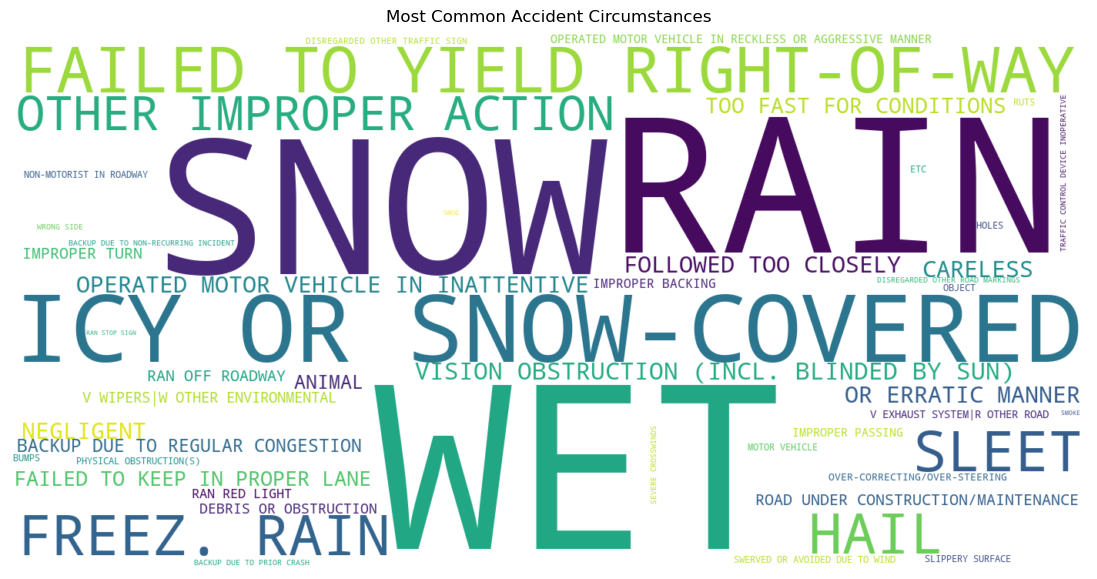

In [124]:
#Hago un gráfico de nube de palabras, más visual para representar esta variable
freq_dict = circ_freq.head(50).to_dict()

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white'
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Accident Circumstances')
plt.show()

### Limpio Driver Distracted By

In [125]:
data['Driver Distracted By'] = data['Driver Distracted By'].fillna('UNKNOWN')

#Agrupamos categorías
data['Driver Distracted By'] = data['Driver Distracted By'].replace({

    # NO DISTRACTION
    'NOT DISTRACTED': 'NOT_DISTRACTED',

    # INATTENTIVE / MENTAL
    'INATTENTIVE OR LOST IN THOUGHT': 'INATTENTIVE',
    'LOOKED BUT DID NOT SEE': 'INATTENTIVE',

    # MOBILE PHONE
    'TALKING/LISTENING': 'CELL_PHONE',
    'TALKING OR LISTENING TO CELLULAR PHONE': 'CELL_PHONE',
    'DIALING CELLULAR PHONE': 'CELL_PHONE',
    'TEXTING FROM A CELLULAR PHONE': 'CELL_PHONE',
    'OTHER CELLULAR PHONE RELATED': 'CELL_PHONE',

    # OTHER ELECTRONIC DEVICES
    'OTHER ELECTRONIC DEVICE (NAVIGATIONAL PALM PILOT)': 'VEHICLE_CONTROL',
    'USING DEVICE OBJECT BROUGHT INTO VEHICLE': 'VEHICLE_CONTROL',
    'USING OTHER DEVICE CONTROLS INTEGRAL TO VEHICLE': 'VEHICLE_CONTROL',
    'ADJUSTING AUDIO AND OR CLIMATE CONTROLS': 'VEHICLE_CONTROL',

    # EXTERNAL DISTRACTIONS
    'DISTRACTED BY OUTSIDE PERSON OBJECT OR EVENT': 'EXTERNAL_DISTRACTION',

    # PASSENGERS
    'BY OTHER OCCUPANTS': 'PASSENGER_DISTRACTION',

    # MOVEMENT INSIDE VEHICLE
    'BY MOVING OBJECT IN VEHICLE': 'OTHER_DISTRACTION',

    # EATING / SMOKING
    'EATING OR DRINKING': 'EATING_DRINKING',
    'SMOKING RELATED': 'EATING_DRINKING',

    # GENERIC OTHER
    'OTHER DISTRACTION': 'OTHER',
    'OTHER ACTION (LOOKING AWAY FROM TASK, ETC.)': 'OTHER',

    # EDGE CASE
    'NO DRIVER PRESENT': 'OTHER'
})

# Aseguramps categorías finales
final_categories = [
    'NOT_DISTRACTED',
    'UNKNOWN',
    'INATTENTIVE',
    'CELL_PHONE',
    'EXTERNAL_DISTRACTION',
    'PASSENGER_DISTRACTION',
    'VEHICLE_CONTROL',
    'EATING_DRINKING',
    'OTHER'
]

data['Driver Distracted By'] = data['Driver Distracted By'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

#Comprobamos
print(data['Driver Distracted By'].value_counts())

Driver Distracted By
NOT_DISTRACTED           127748
UNKNOWN                   42543
INATTENTIVE               25856
OTHER                      4679
EXTERNAL_DISTRACTION        969
CELL_PHONE                  841
VEHICLE_CONTROL             614
PASSENGER_DISTRACTION       418
EATING_DRINKING             222
Name: count, dtype: int64


### Limpio Drivers License State

In [126]:
#En esta variable quiero mantener la granularidad que tiene, pero quiero quitar valores raros como XX o US, que es muy ambiguo
data['Drivers License State'] = data['Drivers License State'].replace({
    'XX': 'UNKNOWN',
    'US': 'UNKNOWN'
})

data['Drivers License State'] = data['Drivers License State'].fillna('UNKNOWN')

In [127]:
#Tambien hay valores duplicados como CA-QC Y QC
data['Drivers License State'] = data['Drivers License State'].replace({
    'CA-QC': 'QC',
    'CA-ON': 'ON'
})
print(data['Drivers License State'].value_counts().head(20))

Drivers License State
MD         168217
UNKNOWN     15730
DC           5933
VA           5835
PA           1265
FL            884
NY            628
WV            530
NC            468
MA            462
NJ            424
CA            407
TX            394
GA            298
DE            219
OH            200
SC            167
WA            148
IL            129
MI            111
Name: count, dtype: int64


### Limpio Vehicle Damage Extent

In [128]:
# Está casi limpia, la limpio minimamente
data['Vehicle Damage Extent'] = data['Vehicle Damage Extent'].fillna('UNKNOWN')

#OTHER → UNKNOWN
data['Vehicle Damage Extent'] = data['Vehicle Damage Extent'].replace({
    'OTHER': 'UNKNOWN'
})

#Check
print(data['Vehicle Damage Extent'].value_counts())

Vehicle Damage Extent
DISABLING               75744
SUPERFICIAL             52416
FUNCTIONAL              52250
DESTROYED                7608
UNKNOWN                  7036
NO DAMAGE                6591
VEHICLE NOT AT SCENE     2245
Name: count, dtype: int64


### Limpio Vehicle First Impact Location

In [129]:
# Unificar formato "O CLOCK" → "OCLOCK"
data['Vehicle First Impact Location'] = data['Vehicle First Impact Location'].str.replace('O CLOCK', 'OCLOCK')

# Unificar duplicados manuales
data['Vehicle First Impact Location'] = data['Vehicle First Impact Location'].replace({
    'ROOF TOP': 'TOP'
})

#NaN → UNKNOWN
data['Vehicle First Impact Location'] = data['Vehicle First Impact Location'].fillna('UNKNOWN')

#Agrupar valores raros en OTHER
valid_values = [
    'ONE OCLOCK','TWO OCLOCK','THREE OCLOCK','FOUR OCLOCK','FIVE OCLOCK',
    'SIX OCLOCK','SEVEN OCLOCK','EIGHT OCLOCK','NINE OCLOCK',
    'TEN OCLOCK','ELEVEN OCLOCK','TWELVE OCLOCK',
    'TOP','UNDERSIDE',
    'VEHICLE NOT AT SCENE',
    'NON-COLLISION',
    'UNKNOWN'
]

data['Vehicle First Impact Location'] = data['Vehicle First Impact Location'].apply(
    lambda x: x if x in valid_values else 'OTHER'
)

#Check
print(data['Vehicle First Impact Location'].value_counts())

Vehicle First Impact Location
TWELVE OCLOCK           77356
SIX OCLOCK              38740
ONE OCLOCK              19589
ELEVEN OCLOCK           17080
TEN OCLOCK               7497
TWO OCLOCK               7469
SEVEN OCLOCK             5410
FIVE OCLOCK              5059
FOUR OCLOCK              4943
EIGHT OCLOCK             4483
NINE OCLOCK              4406
THREE OCLOCK             4392
UNKNOWN                  3238
VEHICLE NOT AT SCENE     2245
NON-COLLISION             743
UNDERSIDE                 660
TOP                       550
OTHER                      30
Name: count, dtype: int64


### Limpio Vehicle Body Type

In [130]:
#Agrupo valores porque hay demasiados y duplicados
#NaN -> UNKNOWN
data['Vehicle Body Type'] = data['Vehicle Body Type'].fillna('UNKNOWN')

#Agrupar categorías
data['Vehicle Body Type'] = data['Vehicle Body Type'].replace({

    # PASSENGER CAR
    'PASSENGER CAR': 'PASSENGER_CAR',
    'STATION WAGON': 'PASSENGER_CAR',
    'LOW SPEED VEHICLE': 'PASSENGER_CAR',
    'LIMOUSINE': 'PASSENGER_CAR',

    # SUV
    'SPORT UTILITY VEHICLE': 'SUV',
    '(SPORT) UTILITY VEHICLE': 'SUV',

    # PICKUP
    'PICKUP': 'PICKUP',
    'PICKUP TRUCK': 'PICKUP',

    # VAN
    'VAN': 'VAN',
    'VAN - CARGO': 'VAN',
    'VAN - PASSENGER (&LT";"9 SEATS)': 'VAN',
    'VAN - PASSENGER (9 OR 12 SEATS)': 'VAN',
    'VAN - PASSENGER (15 SEATS)': 'VAN',
    'CARGO VAN/LIGHT TRUCK 2 AXLES (OVER 10,000LBS (4,536 KG))': 'VAN',

    # BUS
    'BUS - TRANSIT': 'BUS',
    'TRANSIT BUS': 'BUS',
    'BUS - SCHOOL': 'BUS',
    'SCHOOL BUS': 'BUS',
    'BUS - MINI': 'BUS',
    'BUS - OTHER TYPE': 'BUS',
    'OTHER BUS': 'BUS',
    'CROSS COUNTRY BUS': 'BUS',
    'BUS - CROSS COUNTRY': 'BUS',

    # TRUCK
    'OTHER TRUCKS': 'TRUCK',
    'TRUCK TRACTOR': 'TRUCK',
    'SINGLE-UNIT TRUCK': 'TRUCK',
    'OTHER LIGHT TRUCKS (10,000LBS (4,536KG) OR LESS)': 'TRUCK',
    'MEDIUM/HEAVY TRUCKS 3 AXLES (OVER 10,000LBS (4,536KG))': 'TRUCK',
    'FARM VEHICLE': 'TRUCK',
    'FARM EQUIPMENT (TRACTOR, COMBINE HARVESTER, ETC.)': 'TRUCK',
    'CONSTRUCTION EQUIPMENT (BACKHOE, BULLDOZER, ETC.)': 'TRUCK',

    # MOTORCYCLE / 2-3 wheels
    'MOTORCYCLE': 'MOTORCYCLE',
    'MOTORCYCLE - 2 WHEELED': 'MOTORCYCLE',
    'MOTORCYCLE - 3 WHEELED': 'MOTORCYCLE',
    'MOPED': 'MOTORCYCLE',
    'MOPED OR MOTORIZED BICYCLE': 'MOTORCYCLE',
    'AUTOCYCLE': 'MOTORCYCLE',

    # EMERGENCY
    'POLICE VEHICLE/EMERGENCY': 'EMERGENCY',
    'POLICE VEHICLE/NON EMERGENCY': 'EMERGENCY',
    'AMBULANCE/EMERGENCY': 'EMERGENCY',
    'AMBULANCE/NON EMERGENCY': 'EMERGENCY',
    'FIRE VEHICLE/EMERGENCY': 'EMERGENCY',
    'FIRE VEHICLE/NON EMERGENCY': 'EMERGENCY',

    # OFFROAD / SPECIAL
    'ALL-TERRAIN VEHICLE/ALL-TERRAIN CYCLE (ATV/ATC)': 'OFFROAD_SPECIAL',
    'ALL TERRAIN VEHICLE (ATV)': 'OFFROAD_SPECIAL',
    'RECREATIONAL VEHICLE': 'OFFROAD_SPECIAL',
    'RECREATIONAL OFF-HIGHWAY VEHICLES (ROV)': 'OFFROAD_SPECIAL',
    'SNOWMOBILE': 'OFFROAD_SPECIAL',
    'GOLF CART': 'OFFROAD_SPECIAL'
})

#Categorías finales permitidas
final_categories = [
    'PASSENGER_CAR',
    'SUV',
    'PICKUP',
    'VAN',
    'BUS',
    'TRUCK',
    'MOTORCYCLE',
    'EMERGENCY',
    'OFFROAD_SPECIAL',
    'OTHER',
    'UNKNOWN'
]

#Todo lo que no esté ahí -> OTHER
data['Vehicle Body Type'] = data['Vehicle Body Type'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

#Comprobar
print(data['Vehicle Body Type'].value_counts())

Vehicle Body Type
PASSENGER_CAR      140492
SUV                 21079
BUS                  8638
PICKUP               8424
VAN                  7733
EMERGENCY            5000
TRUCK                4693
UNKNOWN              4257
OTHER                1837
MOTORCYCLE           1250
OFFROAD_SPECIAL       487
Name: count, dtype: int64


### Limpio Vehicle Movement

In [131]:
#NaN → UNKNOWN
data['Vehicle Movement'] = data['Vehicle Movement'].fillna('UNKNOWN')

#Agrupar duplicados / equivalentes
data['Vehicle Movement'] = data['Vehicle Movement'].replace({

    # STOPPED
    'STOPPED IN TRAFFIC': 'STOPPED',
    'STOPPED IN TRAFFIC LANE': 'STOPPED',

    # TURNING LEFT
    'TURNING LEFT': 'TURNING_LEFT',
    'MAKING LEFT TURN': 'TURNING_LEFT',

    # TURNING RIGHT
    'TURNING RIGHT': 'TURNING_RIGHT',
    'MAKING RIGHT TURN': 'TURNING_RIGHT',
    'RIGHT TURN ON RED': 'TURNING_RIGHT',

    # U TURN
    'MAKING U-TURN': 'U_TURN',
    'MAKING U TURN': 'U_TURN',

    # PASSING
    'PASSING': 'PASSING',
    'OVERTAKING/PASSING': 'PASSING',

    # STARTING
    'STARTING FROM LANE': 'STARTING',
    'STARTING FROM PARKED': 'STARTING',

    # PARKED
    'PARKING': 'PARKED',
    'PARKED': 'PARKED',

    # ENTERING / LEAVING TRAFFIC
    'ENTERING TRAFFIC LANE': 'ENTERING_LEAVING_TRAFFIC',
    'LEAVING TRAFFIC LANE': 'ENTERING_LEAVING_TRAFFIC',

    # SLOWING
    'SLOWING OR STOPPING': 'SLOWING_STOPPING',

    # KEEP ORIGINALS BIEN DEFINIDOS
    'MOVING CONSTANT SPEED': 'MOVING_CONSTANT_SPEED',
    'ACCELERATING': 'ACCELERATING',
    'BACKING': 'BACKING',
    'CHANGING LANES': 'CHANGING_LANES',
    'NEGOTIATING A CURVE': 'NEGOTIATING_CURVE',
    'SKIDDING': 'SKIDDING',
    'DRIVERLESS MOVING VEH.': 'DRIVERLESS',

    # OTHER
    'OTHER': 'OTHER'
})

#Categorías finales permitidas
final_categories = [
    'MOVING_CONSTANT_SPEED',
    'SLOWING_STOPPING',
    'STOPPED',
    'ACCELERATING',
    'TURNING_LEFT',
    'TURNING_RIGHT',
    'U_TURN',
    'CHANGING_LANES',
    'PASSING',
    'BACKING',
    'STARTING',
    'PARKED',
    'ENTERING_LEAVING_TRAFFIC',
    'NEGOTIATING_CURVE',
    'SKIDDING',
    'DRIVERLESS',
    'OTHER',
    'UNKNOWN'
]

#Todo lo que no esté en lista → OTHER
data['Vehicle Movement'] = data['Vehicle Movement'].apply(
    lambda x: x if x in final_categories else 'OTHER'
)

#Check
print(data['Vehicle Movement'].value_counts())

Vehicle Movement
MOVING_CONSTANT_SPEED       79623
SLOWING_STOPPING            28246
STOPPED                     21038
TURNING_LEFT                20212
ACCELERATING                11715
BACKING                      7052
TURNING_RIGHT                6921
STARTING                     6399
CHANGING_LANES               5808
PARKED                       5308
UNKNOWN                      4269
ENTERING_LEAVING_TRAFFIC     1873
U_TURN                       1545
PASSING                      1313
NEGOTIATING_CURVE             943
OTHER                         898
SKIDDING                      690
DRIVERLESS                     37
Name: count, dtype: int64


### Limpio Going Dir

In [132]:
# Hay duplicados claros, como NORTH vs NORTHBOUND. Limpio esto
# NaN → UNKNOWN
data['Vehicle Going Dir'] = data['Vehicle Going Dir'].fillna('UNKNOWN')

#Unificar direcciones
data['Vehicle Going Dir'] = data['Vehicle Going Dir'].replace({

    'NORTHBOUND': 'NORTH',
    'SOUTHBOUND': 'SOUTH',
    'EASTBOUND': 'EAST',
    'WESTBOUND': 'WEST',

    'NOT ON ROADWAY': 'NOT_ON_ROADWAY'
})

#Categorías finales permitidas
final_categories = [
    'NORTH',
    'SOUTH',
    'EAST',
    'WEST',
    'NOT_ON_ROADWAY',
    'UNKNOWN'
]

#Todo lo demás → UNKNOWN
data['Vehicle Going Dir'] = data['Vehicle Going Dir'].apply(
    lambda x: x if x in final_categories else 'UNKNOWN'
)

#Check
print(data['Vehicle Going Dir'].value_counts())

Vehicle Going Dir
NORTH             54875
SOUTH             53259
EAST              40321
WEST              39441
UNKNOWN           14164
NOT_ON_ROADWAY     1830
Name: count, dtype: int64


### Limpio Speed Limit

In [133]:
#Esta está bien, en formato int y con sus valores bien puestos. No lo limpio

### Limpio DriverLess Vehicle

In [134]:
# Esta variable me parece que no da información, asi que la quito
data = data.drop(columns=['Driverless Vehicle'])

### Limpio Parked Vehicle

In [135]:
# La voy a convertir en binaria. Asumo unknown como un 0
data['Parked Vehicle'] = data['Parked Vehicle'].str.strip().str.upper()

# 2. Ver valores antes de mapear
print(data['Parked Vehicle'].value_counts(dropna=False))

# 3. NaN → NO
data['Parked Vehicle'] = data['Parked Vehicle'].fillna('NO')

# 4. Mapear
data['Parked Vehicle'] = data['Parked Vehicle'].map({
    'NO': 0,
    'YES': 1
})

# 5. Comprobar
print(data['Parked Vehicle'].value_counts())

Parked Vehicle
NO     199029
YES      3335
NaN      1526
Name: count, dtype: int64
Parked Vehicle
0    200555
1      3335
Name: count, dtype: int64


### Limpio Vehicle Year

In [136]:
# Hay algunos años que me parece que están mal escritos, asi que voy a definir un rango de valores validos.
# 1. Asegurar numérico
data['Vehicle Year'] = pd.to_numeric(data['Vehicle Year'], errors='coerce')

# 2. Definir rango válido
min_year = 1960
max_year = 2025

# 3. Filtrar valores inválidos
data.loc[
    (data['Vehicle Year'] < min_year) | 
    (data['Vehicle Year'] > max_year),
    'Vehicle Year'
] = np.nan

# 4. Comprobar
print(data['Vehicle Year'].describe())
print(data['Vehicle Year'].isna().sum())

count    198727.000000
mean       2011.313702
std           6.566341
min        1960.000000
25%        2007.000000
50%        2012.000000
75%        2016.000000
max        2025.000000
Name: Vehicle Year, dtype: float64
5163


### Limpio Vehicle Make

In [137]:
#Esta variable tiene demasiadas categorias y seguro  que da overfitting.
# Voy a intentar limpiarla un poco
data['Vehicle Make'] = data['Vehicle Make'].replace({
    'TOYT': 'TOYOTA',
    'HOND': 'HONDA',
    'CHEV': 'CHEVROLET'
})

In [138]:
data['Vehicle Make'] = data['Vehicle Make'].replace({
    'CHEVY': 'CHEVROLET',
    'NISS': 'NISSAN',
    'HYUN': 'HYUNDAI',
    'MERZ': 'MERCEDES'
})

In [139]:
data['Vehicle Make'] = data['Vehicle Make'].fillna('UNKNOWN')

In [140]:
#Me voy a quedar con las marcas más grandes
top_makes = data['Vehicle Make'].value_counts().nlargest(15)

print(top_makes)

Vehicle Make
TOYOTA       38100
HONDA        29230
FORD         20074
NISSAN       12977
CHEVROLET    12435
HYUNDAI       7269
DODGE         5162
UNKNOWN       4644
JEEP          4513
BMW           3984
LEXUS         3653
ACURA         3483
KIA           3379
MERCEDES      3073
SUBARU        2970
Name: count, dtype: int64


In [141]:
#Thomas es de autobuses, asi que lo pongo en other. Al final voy a coger las 15 largest
data['Vehicle Make'] = data['Vehicle Make'].replace({
    'THOMAS': 'OTHER'
})

# 2. recalcular top 15
top_makes = data['Vehicle Make'].value_counts().nlargest(15).index

# 3. agrupar resto
data['Vehicle Make'] = data['Vehicle Make'].apply(
    lambda x: x if x in top_makes else 'OTHER'
)

# 4. check final
print(data['Vehicle Make'].value_counts())

Vehicle Make
OTHER        48944
TOYOTA       38100
HONDA        29230
FORD         20074
NISSAN       12977
CHEVROLET    12435
HYUNDAI       7269
DODGE         5162
UNKNOWN       4644
JEEP          4513
BMW           3984
LEXUS         3653
ACURA         3483
KIA           3379
MERCEDES      3073
SUBARU        2970
Name: count, dtype: int64


In [142]:
print(len(top_makes))
print(top_makes)

15
Index(['TOYOTA', 'HONDA', 'FORD', 'NISSAN', 'CHEVROLET', 'HYUNDAI', 'DODGE',
       'UNKNOWN', 'JEEP', 'BMW', 'LEXUS', 'ACURA', 'KIA', 'MERCEDES',
       'SUBARU'],
      dtype='object', name='Vehicle Make')


### Limpio Vehicle Model

In [144]:
#Esta variable tiene demasiadas categorias y seguro que da overfitting. Esta variable la voy a eliminar
#porque es demasaido granular y no aporta valor generalizable.
data = data.drop(columns=['Vehicle Model'])

### Limpio Latitude y Longitd

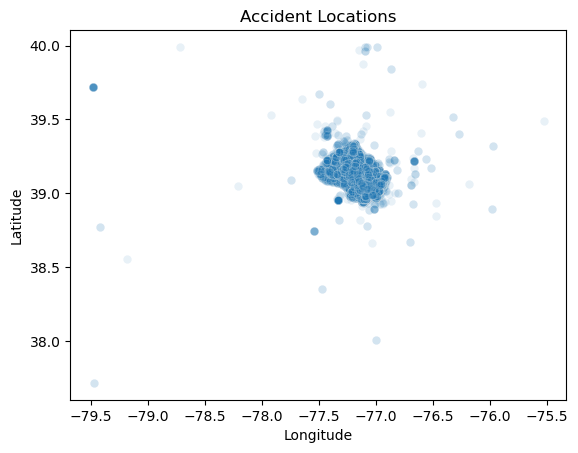

In [145]:
#No limpio, hago un gráfico para verlo
sns.scatterplot(x=data['Longitude'], y=data['Latitude'], alpha=0.1)
plt.title("Accident Locations")
plt.show()

### Limpio Location

In [146]:
#La elimino
data.drop(columns=['Location'], inplace=True)

In [147]:
data.shape

(203890, 29)

## FEATURE ENGINEERING

In [148]:
#Ahora voy a crear variables que creo que van a ser más útiles

In [149]:
# Lo primero voy a crear variables desde la de Crush Date/Time
#Primero creo una que me diga la hora
data['hour'] = data['Crash Date/Time'].dt.hour
#Luego creo una que me diga el dia de la semana que es (0=lunes, 6=domingo)
data['day_of_week'] = data['Crash Date/Time'].dt.dayofweek
#Voy a crear otra que me diga si es fin de semana
data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)
#Crearé una que me diga si es de noche
data['is_night'] = ((data['hour'] < 6) | (data['hour'] > 20)).astype(int)
#Por último creo una que me diga que mes es
data['month'] = data['Crash Date/Time'].dt.month

In [150]:
# Ahora hago una variable de las calles con más accidentes (top 10)
top_roads = data['Road Name'].value_counts().nlargest(10).index

data['Road_Top'] = data['Road Name'].isin(top_roads).astype(int)

In [151]:
#Hago lo mismo para Cross-Street Name
top_cross = data['Cross-Street Name'].value_counts().nlargest(10).index

data['Top_Cross_Street'] = data['Cross-Street Name'].isin(top_cross).astype(int)


In [152]:
# Creo la variable de Vehicle Age, que es el año actual menos el año en el que se hizo el coche. 
data['Crash Date/Time'] = pd.to_datetime(data['Crash Date/Time'])
data['Crash_Year'] = data['Crash Date/Time'].dt.year
data['Vehicle Age'] = data['Crash_Year'] - data['Vehicle Year']
data[['Vehicle Age']].head(10)

,Vehicle Age
0,12.0
1,NaN
2,2.0
3,22.0
4,2.0
5,9.0
6,0.0
7,4.0
8,3.0
9,7.0


In [153]:
(data['Vehicle Age'] < 0).sum()

np.int64(694)

In [154]:
#Elimino los años que tienen menos de 0 años porque no tienen sentido, son un 0,3% del dataset asi que no pasa nada si lo elimino
data.loc[data['Vehicle Age'] < 0, 'Vehicle Age'] = np.nan
#Quito también los outliers, de más de 50 años
data.loc[data['Vehicle Age'] > 50, 'Vehicle Age'] = np.nan

In [155]:
#La variable Circumstance da muchos problemas (es multietiqueta y está contaminada)
#Por esto la voy a transformar en variables columnas 0/1
# 2. Mantener NaN como string temporal para poder buscar
circ = data['Circumstance'].fillna('')

# 3. Crear variables binarias principales
data['circ_speeding'] = circ.str.contains('TOO FAST FOR CONDITIONS', regex=False).astype(int)

data['circ_inattentive'] = circ.str.contains(
    'OPERATED MOTOR VEHICLE IN INATTENTIVE, CARELESS, NEGLIGENT, OR ERRATIC MANNER',
    regex=False
).astype(int)

data['circ_followed_too_closely'] = circ.str.contains('FOLLOWED TOO CLOSELY', regex=False).astype(int)

data['circ_failed_yield'] = circ.str.contains('FAILED TO YIELD RIGHT-OF-WAY', regex=False).astype(int)

data['circ_ran_red_light'] = circ.str.contains('RAN RED LIGHT', regex=False).astype(int)

data['circ_ran_stop_sign'] = circ.str.contains('RAN STOP SIGN', regex=False).astype(int)

data['circ_improper_turn'] = circ.str.contains('IMPROPER TURN', regex=False).astype(int)

data['circ_improper_passing'] = circ.str.contains('IMPROPER PASSING', regex=False).astype(int)

data['circ_improper_backing'] = circ.str.contains('IMPROPER BACKING', regex=False).astype(int)

data['circ_reckless'] = circ.str.contains(
    'OPERATED MOTOR VEHICLE IN RECKLESS OR AGGRESSIVE MANNER',
    regex=False
).astype(int)

data['circ_lane_violation'] = circ.str.contains('FAILED TO KEEP IN PROPER LANE', regex=False).astype(int)

data['circ_ran_off_roadway'] = circ.str.contains('RAN OFF ROADWAY', regex=False).astype(int)

data['circ_wrong_way'] = circ.str.contains('WRONG WAY', regex=False).astype(int)

data['circ_wrong_side'] = circ.str.contains('WRONG SIDE', regex=False).astype(int)

data['circ_overcorrecting'] = circ.str.contains('OVER-CORRECTING/OVER-STEERING', regex=False).astype(int)

# 4. Flags de entorno / obstrucción / condiciones mezcladas
data['circ_vision_obstruction'] = circ.str.contains('VISION OBSTRUCTION', regex=False).astype(int)

data['circ_animal'] = circ.str.contains('ANIMAL', regex=False).astype(int)

data['circ_debris_obstruction'] = circ.str.contains('DEBRIS OR OBSTRUCTION', regex=False).astype(int)

data['circ_road_construction'] = circ.str.contains('ROAD UNDER CONSTRUCTION/MAINTENANCE', regex=False).astype(int)

data['circ_weather_related'] = circ.str.contains(
    'RAIN|SNOW|SLEET|FREEZ|ICY|WET|SMOG|SMOKE|SEVERE CROSSWINDS|BLOWING SNOW|BLOWING SAND',
    regex=True
).astype(int)

# 5. Indicador de missing
data['circ_unknown'] = (data['Circumstance'] == 'UNKNOWN').astype(int)


# Creo una también que me dice si el conductor tiene la culpa
data['circ_driver_error'] = (
    data['circ_speeding'] +
    data['circ_inattentive'] +
    data['circ_reckless']
)

# 6. Verificar
cols_circ = [col for col in data.columns if col.startswith('circ_')]
print(data[cols_circ].sum().sort_values(ascending=False))

circ_unknown                 164619
circ_weather_related          26979
circ_driver_error              2507
circ_failed_yield              2112
circ_vision_obstruction        1241
circ_inattentive               1174
circ_followed_too_closely      1161
circ_speeding                   989
circ_lane_violation             938
circ_animal                     820
circ_ran_off_roadway            562
circ_road_construction          548
circ_improper_turn              546
circ_debris_obstruction         437
circ_ran_red_light              402
circ_improper_backing           377
circ_reckless                   344
circ_improper_passing           323
circ_overcorrecting             251
circ_wrong_side                 128
circ_ran_stop_sign               78
circ_wrong_way                   52
dtype: int64


In [156]:
# Creo que igual son demasiadas variables asi que igual intento reducirlas un poco mas
# 1. Driver behavior (muy importante)
data['circ_driver_behavior'] = (
    data['circ_speeding'] |
    data['circ_inattentive'] |
    data['circ_reckless']
).astype(int)

# 2. Traffic violations
data['circ_traffic_violation'] = (
    data['circ_ran_red_light'] |
    data['circ_ran_stop_sign'] |
    data['circ_failed_yield']
).astype(int)

# 3. Maneuver errors
data['circ_maneuver_error'] = (
    data['circ_improper_turn'] |
    data['circ_improper_passing'] |
    data['circ_improper_backing']
).astype(int)

# 4. Control / loss of vehicle
data['circ_loss_control'] = (
    data['circ_overcorrecting'] |
    data['circ_ran_off_roadway']
).astype(int)

# 5. External factors
data['circ_external'] = (
    data['circ_weather_related'] |
    data['circ_animal'] |
    data['circ_debris_obstruction'] |
    data['circ_road_construction'] |
    data['circ_vision_obstruction']
).astype(int)

In [157]:
data.shape

(203890, 65)

## Eliminamos variables después de Feature Engineering

In [158]:
#Elimino Crash Date time porque ya tengo las variables que me dan información
data.drop('Crash Date/Time', axis=1, inplace=True)

In [159]:
# Creo que elimino Cross Street Name
data.drop('Cross-Street Name', axis=1, inplace=True)

In [160]:
#Como he creado muchas varibales de circumstance, elimino la original
data = data.drop(columns=['Circumstance'])

In [161]:
#Como he creado la variable de Vehicle_age puede eliminar la de vehicle Year
data.drop('Vehicle Year', axis=1, inplace=True)

In [162]:
data.shape

(203890, 61)

# EDA

## Análisis Univariante

Voy a usar la variable Injury Severity para crear mi variable target, para poder predecir cuándo es más probable salir ileso o no ileso de un accidente

In [163]:
data[["Injury Severity"]].head(10)

,Injury Severity
0,NO APPARENT INJURY
1,NaN
2,NO APPARENT INJURY
3,NO APPARENT INJURY
4,NaN
5,NO APPARENT INJURY
6,NO APPARENT INJURY
7,NO APPARENT INJURY
8,NaN
9,NO APPARENT INJURY


In [164]:
data["Injury Severity"].value_counts(dropna=False)

Injury Severity
NO APPARENT INJURY          165678
POSSIBLE INJURY              19635
SUSPECTED MINOR INJURY       14604
NaN                           2115
SUSPECTED SERIOUS INJURY      1672
FATAL INJURY                   186
Name: count, dtype: int64

In [165]:
data['Injury Severity'].value_counts(normalize=True)

Injury Severity
NO APPARENT INJURY          0.821103
POSSIBLE INJURY             0.097311
SUSPECTED MINOR INJURY      0.072378
SUSPECTED SERIOUS INJURY    0.008286
FATAL INJURY                0.000922
Name: proportion, dtype: float64

In [166]:
data["Injury Severity"].describe()

count                 201775
unique                     5
top       NO APPARENT INJURY
freq                  165678
Name: Injury Severity, dtype: object

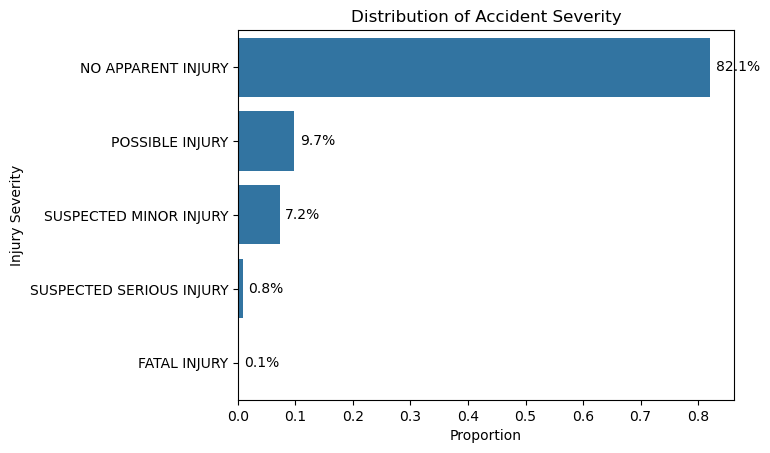

In [167]:
# Hago un grafico de sectores para ver la proporción de cada valor dentro de la variable target.
plt.figure()
counts = data['Injury Severity'].value_counts(normalize=True)
ax = sns.barplot(x=counts.values, y=counts.index)

# añadir etiquetas
for i, v in enumerate(counts.values):
    ax.text(v + 0.01, i, f"{v*100:.1f}%", va='center')

plt.xlabel('Proportion')
plt.ylabel('Injury Severity')
plt.title('Distribution of Accident Severity')

plt.show()

In [168]:
#Aquí estoy creando una nueva variable binaria, que clasifica entre accidente en el que sales ileso (0) o no ileso (1)
data['Injured'] = data['Injury Severity'].isin([
    'FATAL',
    'SUSPECTED SERIOUS INJURY',
    'SUSPECTED MINOR INJURY'
]).astype(int)

In [169]:
data['Injured'].value_counts(normalize=True)

Injured
0    0.920173
1    0.079827
Name: proportion, dtype: float64

In [170]:
#Ahora elimino la variable Injury Severity porque ya cree la variable Injured
data = data.drop(columns=['Injury Severity'])

## Análisis Bivariante

In [171]:
list(data.columns)

['Agency Name',
 'Route Type',
 'Road Name',
 'Collision Type',
 'Weather',
 'Surface Condition',
 'Light',
 'Traffic Control',
 'Driver At Fault',
 'Driver Distracted By',
 'Drivers License State',
 'Vehicle Damage Extent',
 'Vehicle First Impact Location',
 'Vehicle Body Type',
 'Vehicle Movement',
 'Vehicle Going Dir',
 'Speed Limit',
 'Parked Vehicle',
 'Vehicle Make',
 'Latitude',
 'Longitude',
 'NonMotorist_Involved',
 'Driver_Substance_Abuse',
 'NM_Substance_Abuse',
 'hour',
 'day_of_week',
 'is_weekend',
 'is_night',
 'month',
 'Road_Top',
 'Top_Cross_Street',
 'Crash_Year',
 'Vehicle Age',
 'circ_speeding',
 'circ_inattentive',
 'circ_followed_too_closely',
 'circ_failed_yield',
 'circ_ran_red_light',
 'circ_ran_stop_sign',
 'circ_improper_turn',
 'circ_improper_passing',
 'circ_improper_backing',
 'circ_reckless',
 'circ_lane_violation',
 'circ_ran_off_roadway',
 'circ_wrong_way',
 'circ_wrong_side',
 'circ_overcorrecting',
 'circ_vision_obstruction',
 'circ_animal',
 'circ_d

In [172]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203890 entries, 0 to 203889
Data columns (total 61 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Agency Name                    203890 non-null  object 
 1   Route Type                     203890 non-null  object 
 2   Road Name                      180849 non-null  object 
 3   Collision Type                 203890 non-null  object 
 4   Weather                        203890 non-null  object 
 5   Surface Condition              203890 non-null  object 
 6   Light                          203890 non-null  object 
 7   Traffic Control                203890 non-null  object 
 8   Driver At Fault                203890 non-null  int64  
 9   Driver Distracted By           203890 non-null  object 
 10  Drivers License State          203890 non-null  object 
 11  Vehicle Damage Extent          203890 non-null  object 
 12  Vehicle First Impact Location 

In [173]:
#Hago una función para hacer gráficos por variable
def plot_injury_rate_by_category(df, col, target='Injured', top_n=10, figsize=(10,5)):
    temp = df.copy()
    temp[col] = temp[col].fillna('UNKNOWN')
    
    if temp[col].nunique() > top_n:
        top_categories = temp[col].value_counts().head(top_n).index
        temp = temp[temp[col].isin(top_categories)]
    
    order = temp.groupby(col)[target].mean().sort_values(ascending=False).index
    
    plt.figure(figsize=figsize)
    sns.barplot(data=temp, x=col, y=target, order=order, estimator=np.mean)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Proporción de no ileso')
    plt.title(f'Tasa de no salir ileso por {col}')
    plt.tight_layout()
    plt.show()

### Patrones temporales

In [174]:
pd.crosstab(data['day_of_week'], data['Injured'])

Injured,0,1
day_of_week,,
0,27066,2379
1,29273,2422
2,28875,2424
3,29075,2548
4,30357,2550
5,23484,2120
6,19484,1833


In [175]:
pd.crosstab(data['day_of_week'], data['Injured'], normalize='index') * 100

Injured,0,1
day_of_week,,
0,91.920530,8.079470
1,92.358416,7.641584
2,92.255344,7.744656
3,91.942573,8.057427
4,92.250889,7.749111
5,91.720044,8.279956
6,91.401229,8.598771


<Axes: xlabel='day_of_week', ylabel='Injured'>

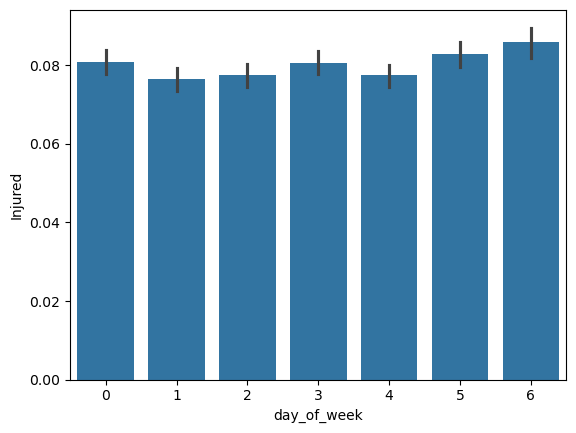

In [176]:
sns.barplot(
    x='day_of_week',
    y='Injured',
    data=data,
    estimator=lambda x: sum(x)/len(x)
)

#Hemos pintado tambien el intervalo de confianza

In [177]:
pd.crosstab(data['is_weekend'], data['Injured'], normalize='index') * 100

Injured,0,1
is_weekend,,
0,92.149405,7.850595
1,91.575201,8.424799


In [178]:
pd.crosstab(data['month'], data['Injured'], normalize='index') * 100

Injured,0,1
month,,
1,92.971983,7.028017
2,92.518720,7.481280
3,92.063687,7.936313
4,91.654604,8.345396
5,90.986226,9.013774
6,90.930576,9.069424
7,91.386756,8.613244
8,91.683816,8.316184
9,91.693723,8.306277


In [179]:
pd.crosstab(data['is_night'], data['Injured'], normalize='index') * 100

Injured,0,1
is_night,,
0,92.240552,7.759448
1,90.721649,9.278351


In [180]:
hourly_table = data.groupby('hour').agg(
    total_accidents=('Injured', 'count'),
    injured_cases=('Injured', 'sum'),
    injury_rate=('Injured', 'mean')
).reset_index()

hourly_table

,hour,total_accidents,injured_cases,injury_rate
0,0,2993,285,0.095222
1,1,2387,233,0.097612
2,2,2059,215,0.104420
3,3,1919,192,0.100052
4,4,1697,167,0.098409
5,5,2910,317,0.108935
6,6,5195,506,0.097401
7,7,9854,843,0.085549
8,8,12403,1004,0.080948
9,9,11000,918,0.083455


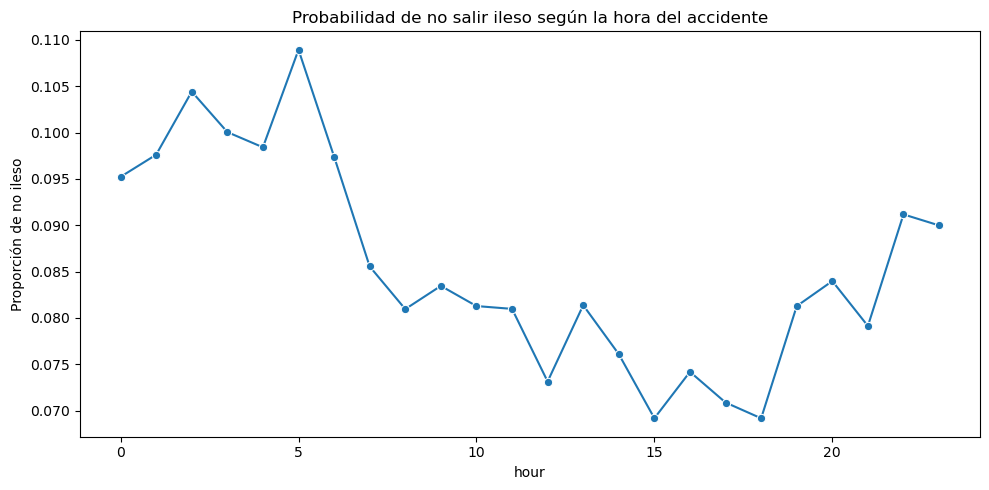

In [181]:
hourly_rate = data.groupby('hour')['Injured'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_rate, x='hour', y='Injured', marker='o')
plt.ylabel('Proporción de no ileso')
plt.title('Probabilidad de no salir ileso según la hora del accidente')
plt.tight_layout()
plt.show()

### Entorno y vía

In [182]:
#Ahora veo si las calles con más accidentes tienen mas o menos accidentes graves
pd.crosstab(data['Road_Top'], data['Injured'], normalize='index')

Injured,0,1
Road_Top,,
0,0.921526,0.078474
1,0.916387,0.083613


In [183]:
pd.crosstab(data['Weather'], data['Injured'], normalize='index') * 100

Injured,0,1
Weather,,
CLEAR,91.954518,8.045482
CLOUDY,91.919694,8.080306
FOG,91.351351,8.648649
OTHER,91.168831,8.831169
RAIN,91.768673,8.231327
SNOW,92.074871,7.925129
UNKNOWN,93.250544,6.749456
WIND,91.573034,8.426966


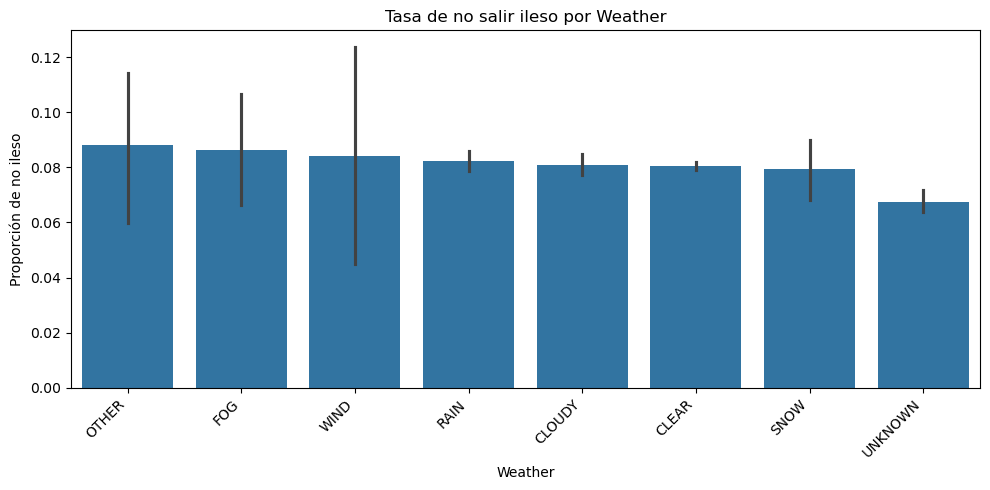

In [184]:
plot_injury_rate_by_category(data, 'Weather')

In [185]:
pd.crosstab(data['Light'], data['Injured'], normalize='index') * 100

Injured,0,1
Light,,
DARK_LIGHTED,91.607097,8.392903
DARK_NOT_LIGHTED,90.667552,9.332448
DARK_UNKNOWN,94.378194,5.621806
DAWN,91.779011,8.220989
DAYLIGHT,92.129903,7.870097
DUSK,92.024822,7.975178
OTHER,93.103448,6.896552
UNKNOWN,95.470693,4.529307


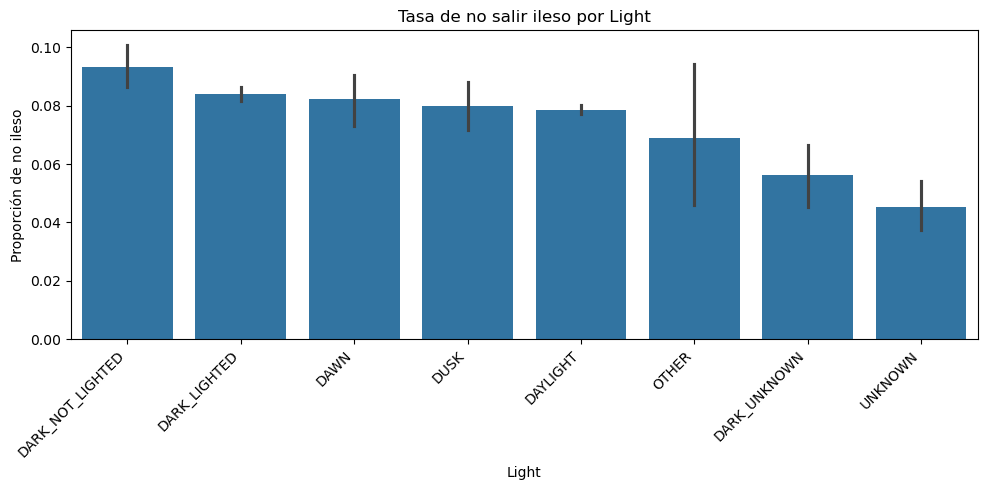

In [186]:
plot_injury_rate_by_category(data, 'Light')

In [187]:
pd.crosstab(data['Surface Condition'], data['Injured'], normalize='index') * 100

Injured,0,1
Surface Condition,,
DRY,91.405237,8.594763
OTHER,88.255034,11.744966
SNOW_ICE,91.831307,8.168693
UNKNOWN,96.715789,3.284211
WET,91.359073,8.640927


In [188]:
pd.crosstab(data['Traffic Control'], data['Injured'], normalize='index') * 100

Injured,0,1
Traffic Control,,
NO_CONTROL,92.333122,7.666878
OTHER,93.044264,6.955736
PEDESTRIAN,90.878378,9.121622
PERSON_CONTROL,96.474359,3.525641
RAILROAD,95.744681,4.255319
SCHOOL_ZONE,93.750000,6.250000
STOP_SIGN,91.226356,8.773644
TRAFFIC_SIGNAL,90.834176,9.165824
UNKNOWN,94.287108,5.712892


In [189]:
pd.crosstab(data['Route Type'], data['Injured'], normalize='index') * 100

Injured,0,1
Route Type,,
COUNTY,91.694133,8.305867
INTERSTATE,91.718310,8.281690
MUNICIPALITY,93.246262,6.753738
OTHER,90.551335,9.448665
STATE,91.107022,8.892978
UNKNOWN,97.188075,2.811925


### Conductor y comportamiento

In [190]:
pd.crosstab(data['Driver At Fault'], data['Injured'], normalize='index') * 100

Injured,0,1
Driver At Fault,,
0,90.868557,9.131443
1,93.143235,6.856765


In [191]:
pd.crosstab(data['Driver Distracted By'], data['Injured'], normalize='index') * 100

Injured,0,1
Driver Distracted By,,
CELL_PHONE,90.011891,9.988109
EATING_DRINKING,87.837838,12.162162
EXTERNAL_DISTRACTION,92.569659,7.430341
INATTENTIVE,94.535118,5.464882
NOT_DISTRACTED,91.339982,8.660018
OTHER,92.284676,7.715324
PASSENGER_DISTRACTION,95.454545,4.545455
UNKNOWN,92.485250,7.514750
VEHICLE_CONTROL,93.485342,6.514658


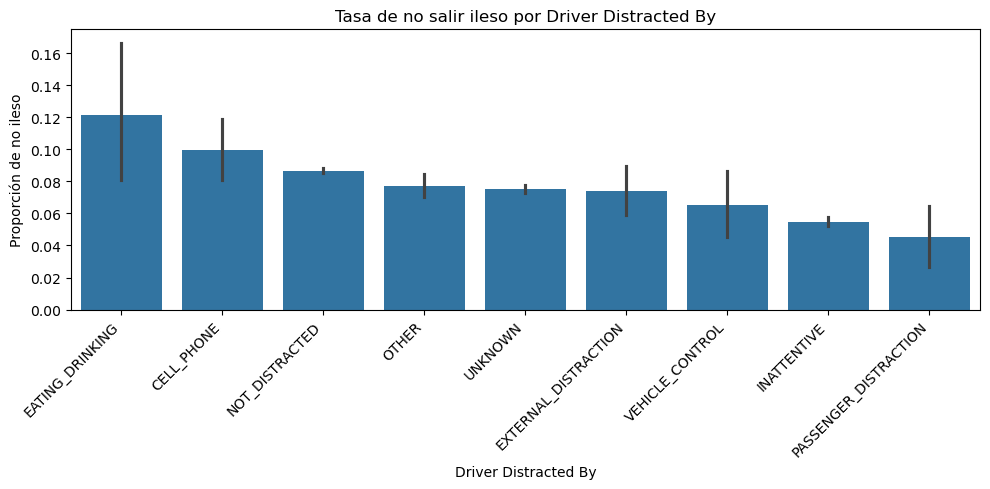

In [192]:
plot_injury_rate_by_category(data, 'Driver Distracted By')

In [193]:
pd.crosstab(data['Driver_Substance_Abuse'], data['Injured'], normalize='index') * 100

Injured,0,1
Driver_Substance_Abuse,,
0,92.096234,7.903766
1,89.847787,10.152213


In [194]:
pd.crosstab(data['circ_driver_behavior'], data['Injured'], normalize='index') * 100

Injured,0,1
circ_driver_behavior,,
0,92.05879,7.94121
1,87.86528,12.13472


In [195]:
pd.crosstab(data['circ_traffic_violation'], data['Injured'], normalize='index') * 100

Injured,0,1
circ_traffic_violation,,
0,92.056400,7.943600
1,88.825911,11.174089


In [196]:
pd.crosstab(data['circ_loss_control'], data['Injured'], normalize='index') * 100

Injured,0,1
circ_loss_control,,
0,92.053857,7.946143
1,82.236842,17.763158


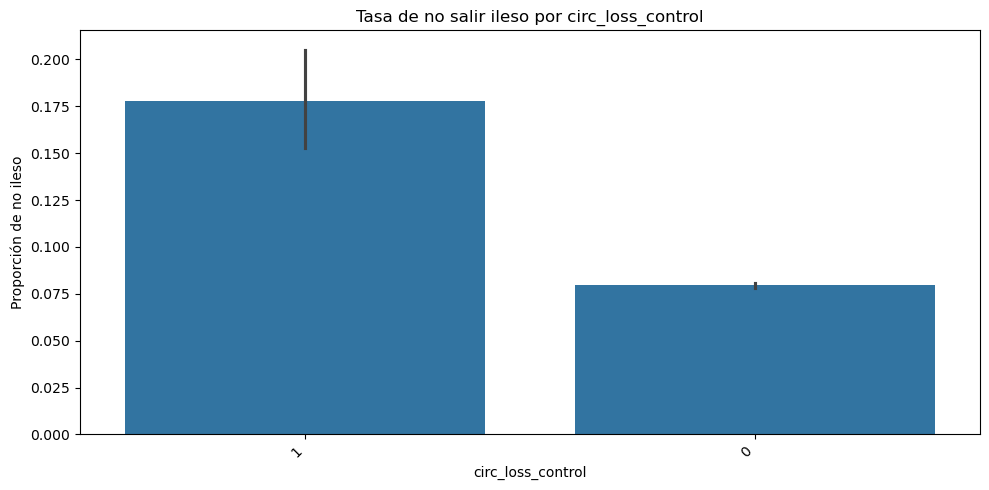

In [197]:
plot_injury_rate_by_category(data, 'circ_loss_control')

### Vehículo y dinámica

In [198]:
pd.crosstab(data['Vehicle Body Type'], data['Injured'], normalize='index') * 100

Injured,0,1
Vehicle Body Type,,
BUS,98.946515,1.053485
EMERGENCY,96.280000,3.720000
MOTORCYCLE,46.400000,53.600000
OFFROAD_SPECIAL,89.322382,10.677618
OTHER,94.120849,5.879151
PASSENGER_CAR,91.276372,8.723628
PICKUP,94.859924,5.140076
SUV,91.128611,8.871389
TRUCK,96.952909,3.047091


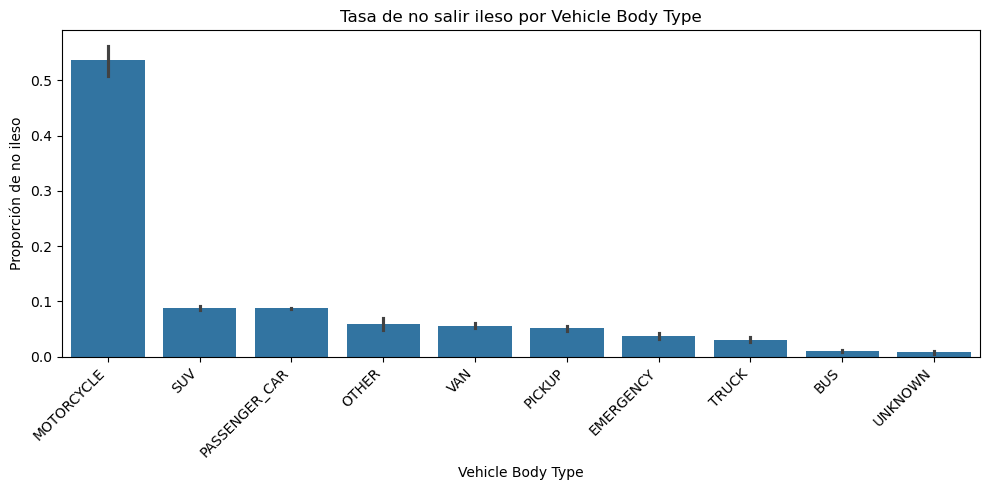

In [199]:
plot_injury_rate_by_category(data, 'Vehicle Body Type')

In [200]:
pd.crosstab(data['Vehicle Movement'], data['Injured'], normalize='index') * 100

Injured,0,1
Vehicle Movement,,
ACCELERATING,91.865130,8.134870
BACKING,99.120817,0.879183
CHANGING_LANES,95.437328,4.562672
DRIVERLESS,91.891892,8.108108
ENTERING_LEAVING_TRAFFIC,91.884677,8.115323
MOVING_CONSTANT_SPEED,89.639928,10.360072
NEGOTIATING_CURVE,86.426299,13.573701
OTHER,94.432071,5.567929
PARKED,97.682743,2.317257


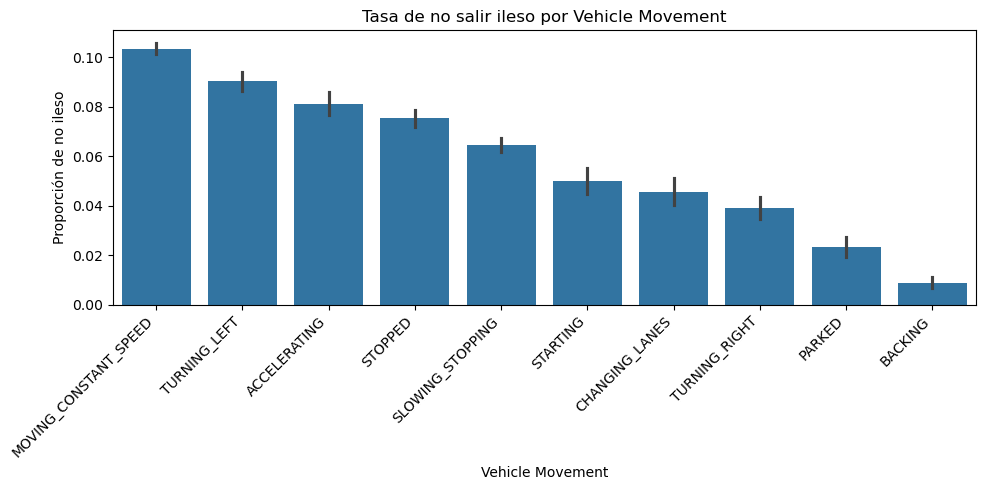

In [201]:
plot_injury_rate_by_category(data, 'Vehicle Movement')

In [202]:
pd.crosstab(data['Collision Type'], data['Injured'], normalize='index') * 100

Injured,0,1
Collision Type,,
ANGLE,90.463745,9.536255
HEAD_ON,85.711974,14.288026
OTHER,95.302077,4.697923
REAR_END,92.947561,7.052439
SIDESWIPE,96.634654,3.365346
SINGLE_VEHICLE,88.850798,11.149202
UNKNOWN,96.086106,3.913894


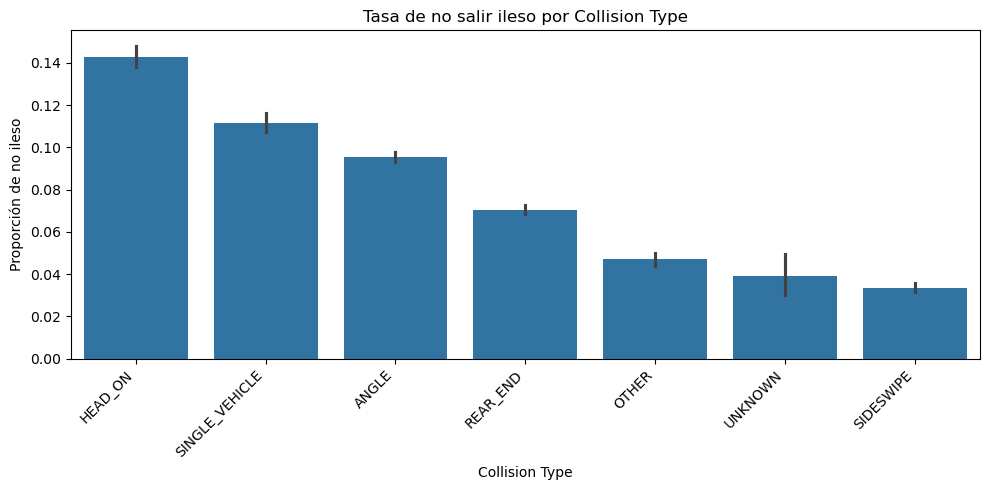

In [203]:
plot_injury_rate_by_category(data, 'Collision Type')

In [204]:
pd.crosstab(data['Parked Vehicle'], data['Injured'], normalize='index') * 100

Injured,0,1
Parked Vehicle,,
0,91.928897,8.071103
1,97.331334,2.668666


In [205]:
pd.crosstab(data['Speed Limit'], data['Injured'], normalize='index') * 100

Injured,0,1
Speed Limit,,
0,96.886611,3.113389
5,98.062457,1.937543
10,97.056118,2.943882
15,97.234265,2.765735
20,94.396015,5.603985
25,93.572440,6.427560
30,91.654492,8.345508
35,91.649688,8.350312
40,90.079103,9.920897


C:\Users\carme\AppData\Local\Temp\ipykernel_10472\3574083978.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = temp.groupby(col)[target].mean().sort_values(ascending=False).index


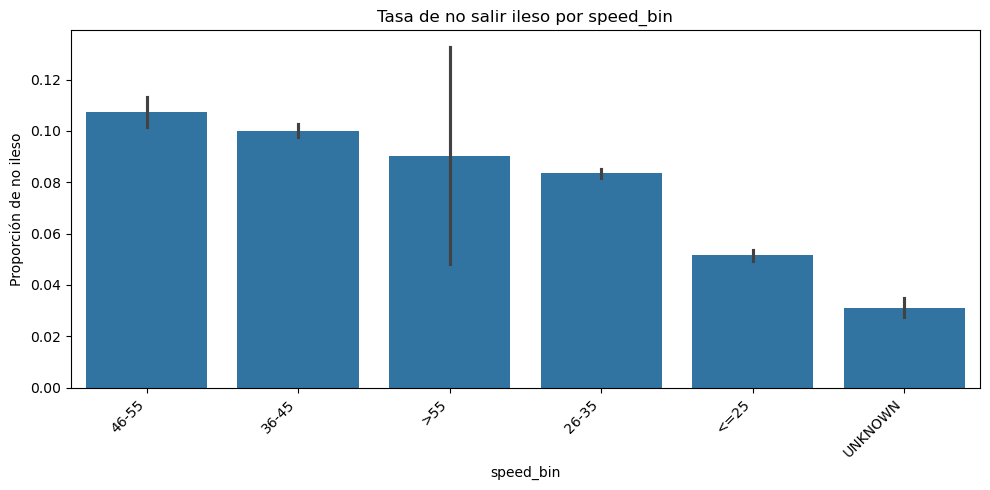

In [206]:
data['speed_bin'] = pd.cut(
    data['Speed Limit'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<=25', '26-35', '36-45', '46-55', '>55']
)

data['speed_bin'] = data['speed_bin'].cat.add_categories(['UNKNOWN'])
data['speed_bin'] = data['speed_bin'].fillna('UNKNOWN')

plot_injury_rate_by_category(data, 'speed_bin')

In [207]:

data['vehicle_age_bin'] = pd.cut(
    data['Vehicle Age'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5', '6-10', '11-20', '>20']
)
pd.crosstab(data['vehicle_age_bin'], data['Injured'], normalize='index') * 100

Injured,0,1
vehicle_age_bin,,
0-5,91.875687,8.124313
6-10,92.102076,7.897924
11-20,91.626311,8.373689
>20,90.902410,9.097590


# MODELIZACION

In [208]:
#Aquí defino el dataset del modelo 
target = 'Injured'

drop_for_model = [
    'Injured',
    'Road Name',              # demasiada granularidad
    'Vehicle Damage Extent',  # opcional: mejor quitarla en el modelo principal
    'Vehicle First Impact Location'  # opcional: mejor quitarla en el modelo principal
]

X = data.drop(columns=drop_for_model, errors='ignore')
y = data[target]

In [209]:
#Separo train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [210]:
#Separo variables numéricas y categóricas
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['Agency Name', 'Route Type', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Distracted By', 'Drivers License State', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Vehicle Make', 'speed_bin', 'vehicle_age_bin']
Numeric: ['Driver At Fault', 'Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'Driver_Substance_Abuse', 'NM_Substance_Abuse', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Road_Top', 'Top_Cross_Street', 'Crash_Year', 'Vehicle Age', 'circ_speeding', 'circ_inattentive', 'circ_followed_too_closely', 'circ_failed_yield', 'circ_ran_red_light', 'circ_ran_stop_sign', 'circ_improper_turn', 'circ_improper_passing', 'circ_improper_backing', 'circ_reckless', 'circ_lane_violation', 'circ_ran_off_roadway', 'circ_wrong_way', 'circ_wrong_side', 'circ_overcorrecting', 'circ_vision_obstruction', 'circ_animal', 'circ_debris_obstruction', 'circ_road_construction', 'circ_weather_relate

In [211]:
#Preproceso con One Hot Encoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [212]:
#Modelo baseline: Logistic Regression - Muy interpretable, baja accuracy
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

C:\Users\carme\anaconda3\envs\tfg\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.96      0.59      0.73     56284
           1       0.13      0.70      0.22      4883

    accuracy                           0.60     61167
   macro avg       0.54      0.65      0.47     61167
weighted avg       0.89      0.60      0.69     61167

ROC-AUC: 0.7117681128063373


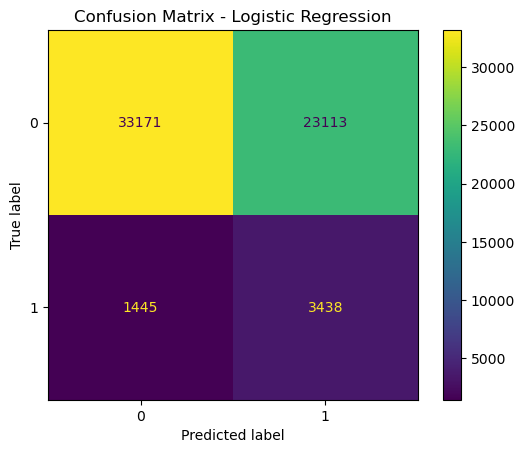

In [213]:
#Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [214]:
#Modelo final: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.96      0.61      0.74     56284
           1       0.14      0.71      0.23      4883

    accuracy                           0.62     61167
   macro avg       0.55      0.66      0.49     61167
weighted avg       0.89      0.62      0.70     61167

ROC-AUC: 0.7188630065339767


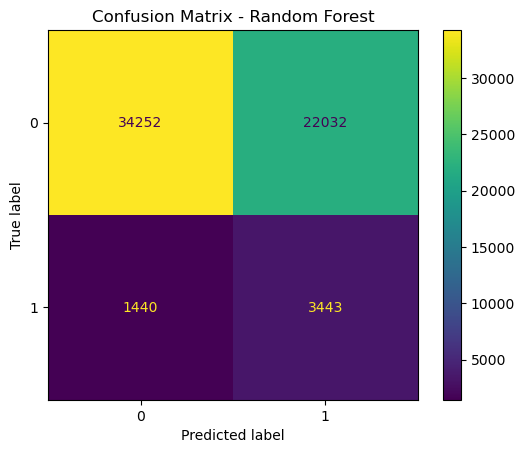

In [215]:
#Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Comparación de modelos

In [216]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.129487,0.704075,0.218744,0.711768
1,Random Forest,0.135152,0.705099,0.226827,0.718863


## Curva ROC

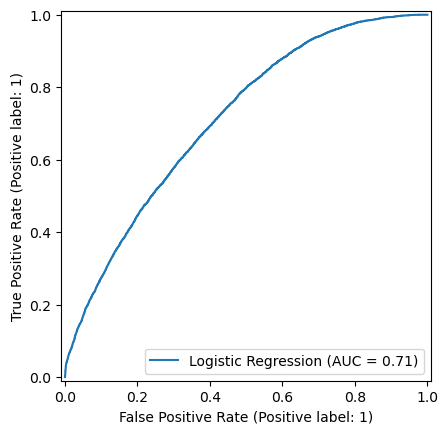

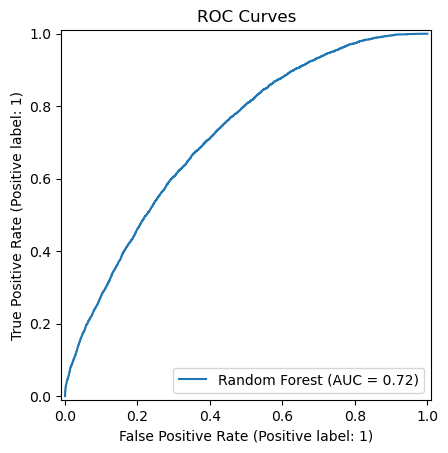

In [217]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob_log, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest')
plt.title('ROC Curves')
plt.show()

### PARA HACER SHAP

In [218]:
#Usaré el Random Forest ya entrenado
#Transformar datos y sacar nombres de las variables
# Sacar preprocesador y clasificador entrenados
fitted_preprocessor = rf_model.named_steps['preprocessor']
fitted_rf = rf_model.named_steps['classifier']

# Transformar X_test
X_test_transformed = fitted_preprocessor.transform(X_test)

# Nombres de las features transformadas
feature_names = fitted_preprocessor.get_feature_names_out()

# Pasar a DataFrame si quieres trabajar más cómodo
X_test_transformed_df = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names
)

In [219]:
#Hago primero SHAP sobre una muestra
sample_size = min(1000, len(X_test_transformed_df))
X_shap = X_test_transformed_df.sample(sample_size, random_state=42)

In [220]:
#SHAP Values
explainer = shap.TreeExplainer(fitted_rf)
shap_values = explainer.shap_values(X_shap)

In [221]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Es una lista")
    print("Número de elementos:", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"Clase {i}: shape = {np.array(sv).shape}")
else:
    print("No es lista")
    print("Shape:", np.array(shap_values).shape)

<class 'numpy.ndarray'>
No es lista
Shape: (1000, 240, 2)


Shape shap_class_1: (1000, 240)
Shape X_shap: (1000, 240)


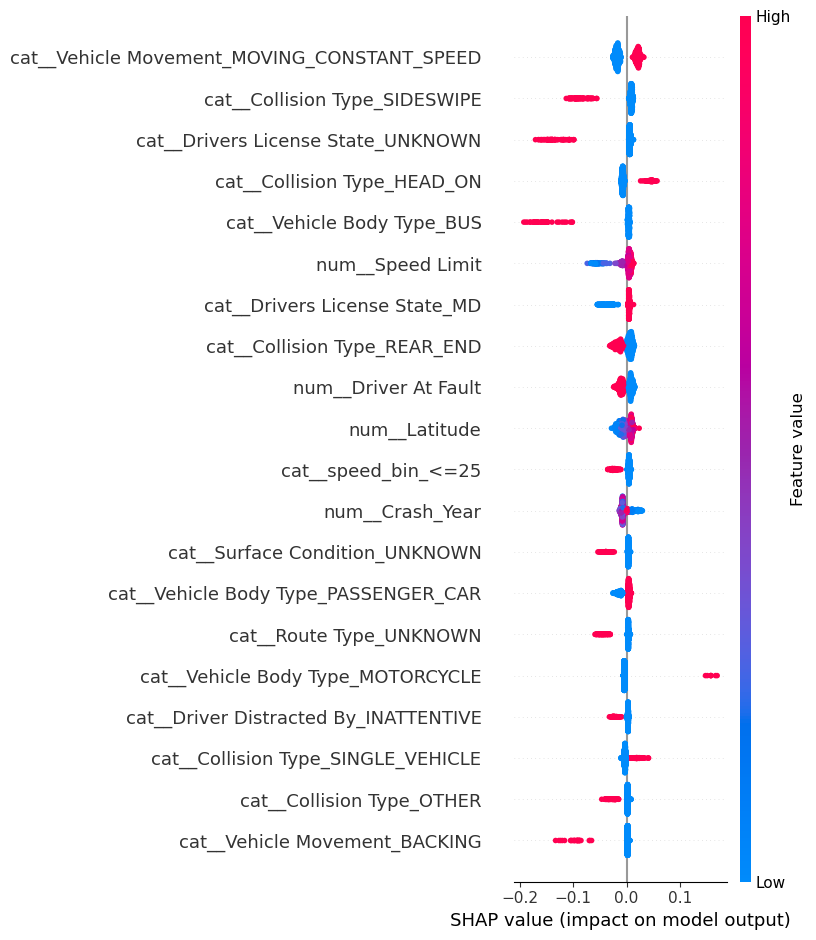

In [222]:
explainer = shap.TreeExplainer(fitted_rf)
shap_values = explainer.shap_values(X_shap)

# coger solo la clase 1 = no ileso
shap_class_1 = shap_values[:, :, 1]

print("Shape shap_class_1:", shap_class_1.shape)
print("Shape X_shap:", X_shap.shape)

shap.summary_plot(shap_class_1, X_shap, plot_type="dot")

## Reformulación: conjunto de variables predictivo y explicativo

### Definición de los conjuntos de variables

In [223]:
# Vuelvo a limpiar un poco mi datase
cols_drop_common = [
    'Injured',
    'Injury Severity',

    'Agency Name',
    'Road Name',
    'Drivers License State',
    'Vehicle Make',
    'Vehicle Damage Extent',

    'Road_Top',
    'Top_Cross_Street',

    'circ_speeding',
    'circ_inattentive',
    'circ_followed_too_closely',
    'circ_failed_yield',
    'circ_ran_red_light',
    'circ_ran_stop_sign',
    'circ_improper_turn',
    'circ_improper_passing',
    'circ_improper_backing',
    'circ_reckless',
    'circ_lane_violation',
    'circ_ran_off_roadway',
    'circ_wrong_way',
    'circ_wrong_side',
    'circ_overcorrecting',
    'circ_vision_obstruction',
    'circ_animal',
    'circ_debris_obstruction',
    'circ_road_construction',
    'circ_weather_related',
    'circ_unknown',
    'circ_driver_error'
]

In [224]:
#Para el modelo predictivo quito otras variables que solo se pueden conocer despues del accidente o tras analizar parte de el
cols_drop_predictive_extra = [
    'Collision Type',
    'Vehicle Movement',
    'Driver At Fault',
    'Vehicle Damage Extent', 
    'Vehicle First Impact Location'
]

In [225]:
#Creo nuevos conjuntos de variables, para el predictivo y para el explicativo
y = data['Injured']

X_predictive = data.drop(
    columns=cols_drop_common + cols_drop_predictive_extra,
    errors='ignore'
)

X_explanatory = data.drop(
    columns=cols_drop_common,
    errors='ignore'
)

In [226]:
#Reviso que variables quedan en cada modelo
#Predictivo
print("Número de variables en X_predictive:", X_predictive.shape[1])
print("Variables predictivas:")
print(X_predictive.columns.tolist())

Número de variables en X_predictive: 29
Variables predictivas:
['Route Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Distracted By', 'Vehicle Body Type', 'Vehicle Going Dir', 'Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'Driver_Substance_Abuse', 'NM_Substance_Abuse', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Crash_Year', 'Vehicle Age', 'circ_driver_behavior', 'circ_traffic_violation', 'circ_maneuver_error', 'circ_loss_control', 'circ_external', 'speed_bin', 'vehicle_age_bin']


In [227]:
#Explicativo
print("Número de variables en X_explanatory:", X_explanatory.shape[1])
print("Variables explicativas:")
print(X_explanatory.columns.tolist())

Número de variables en X_explanatory: 33
Variables explicativas:
['Route Type', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver At Fault', 'Driver Distracted By', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'Driver_Substance_Abuse', 'NM_Substance_Abuse', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Crash_Year', 'Vehicle Age', 'circ_driver_behavior', 'circ_traffic_violation', 'circ_maneuver_error', 'circ_loss_control', 'circ_external', 'speed_bin', 'vehicle_age_bin']


In [228]:
def train_random_forest_model(X, y, model_name):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ]
    )
    
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(model_name)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Average Precision:", average_precision_score(y_test, y_prob))
    
    results = {
        'model_name': model_name,
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'categorical_cols': categorical_cols,
        'numeric_cols': numeric_cols,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'average_precision': average_precision_score(y_test, y_prob),
        'precision_class_1': precision_score(y_test, y_pred),
        'recall_class_1': recall_score(y_test, y_pred),
        'f1_class_1': f1_score(y_test, y_pred)
    }
    
    return results

In [229]:
#Entreno modelo predictivo
results_predictive = train_random_forest_model(
    X_predictive,
    y,
    model_name='Random Forest Predictive'
)

Random Forest Predictive
              precision    recall  f1-score   support

           0       0.95      0.55      0.69     37523
           1       0.12      0.68      0.20      3255

    accuracy                           0.56     40778
   macro avg       0.53      0.61      0.45     40778
weighted avg       0.88      0.56      0.65     40778

ROC-AUC: 0.6692098073345532
Average Precision: 0.16819025638894902


In [230]:
#Entreno modelo explicativo
results_explanatory = train_random_forest_model(
    X_explanatory,
    y,
    model_name='Random Forest Explanatory'
)

Random Forest Explanatory
              precision    recall  f1-score   support

           0       0.96      0.64      0.76     37523
           1       0.14      0.67      0.23      3255

    accuracy                           0.64     40778
   macro avg       0.55      0.66      0.50     40778
weighted avg       0.89      0.64      0.72     40778

ROC-AUC: 0.7170782872219325
Average Precision: 0.1906267793948503


In [231]:
#Comparo métricas entre ambos
comparison_results = pd.DataFrame({
    'Model': [
        results_predictive['model_name'],
        results_explanatory['model_name']
    ],
    'Precision_class_1': [
        results_predictive['precision_class_1'],
        results_explanatory['precision_class_1']
    ],
    'Recall_class_1': [
        results_predictive['recall_class_1'],
        results_explanatory['recall_class_1']
    ],
    'F1_class_1': [
        results_predictive['f1_class_1'],
        results_explanatory['f1_class_1']
    ],
    'ROC_AUC': [
        results_predictive['roc_auc'],
        results_explanatory['roc_auc']
    ],
    'Average_Precision': [
        results_predictive['average_precision'],
        results_explanatory['average_precision']
    ]
})
comparison_results

,Model,Precision_class_1,Recall_class_1,F1_class_1,ROC_AUC,Average_Precision
0,Random Forest Predictive,0.115030,0.681413,0.196832,0.669210,0.168190
1,Random Forest Explanatory,0.138594,0.674962,0.229968,0.717078,0.190627


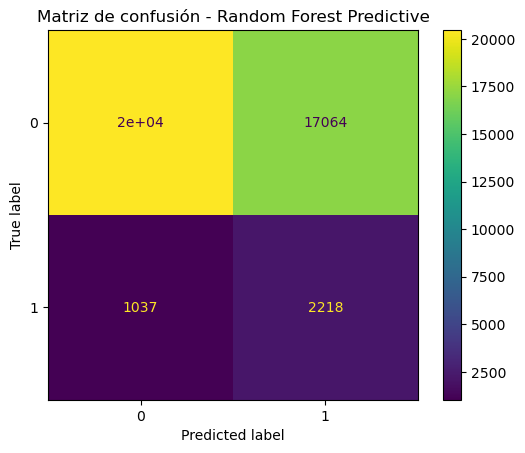

In [232]:
#Matriz de confusión para predictivo
cm_predictive = confusion_matrix(
    results_predictive['y_test'],
    results_predictive['y_pred']
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_predictive)
disp.plot()
plt.title("Matriz de confusión - Random Forest Predictive")
plt.show()

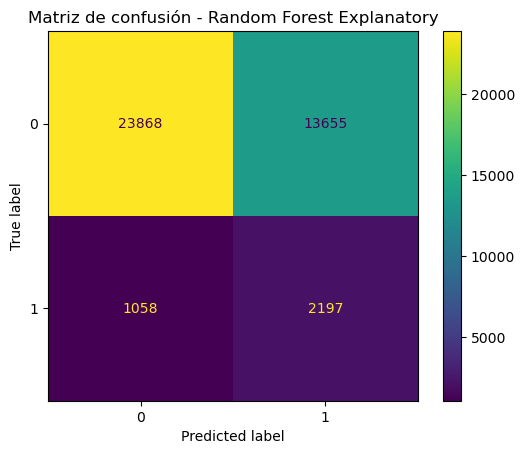

In [233]:
#Matriz de confusión para explicativo
cm_explanatory = confusion_matrix(
    results_explanatory['y_test'],
    results_explanatory['y_pred']
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_explanatory)
disp.plot()
plt.title("Matriz de confusión - Random Forest Explanatory")
plt.show()

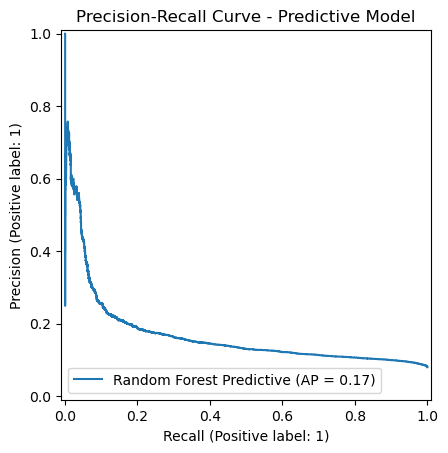

In [234]:
#Curva Preciison-Recall Predictivo
PrecisionRecallDisplay.from_predictions(
    results_predictive['y_test'],
    results_predictive['y_prob'],
    name='Random Forest Predictive'
)

plt.title("Precision-Recall Curve - Predictive Model")
plt.show()

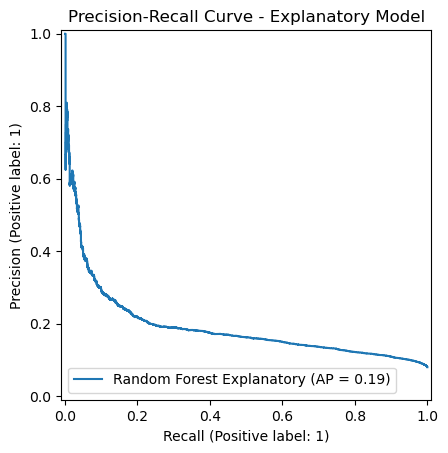

In [235]:
#Curva Precision-Recall Explicativo
PrecisionRecallDisplay.from_predictions(
    results_explanatory['y_test'],
    results_explanatory['y_prob'],
    name='Random Forest Explanatory'
)

plt.title("Precision-Recall Curve - Explanatory Model")
plt.show()

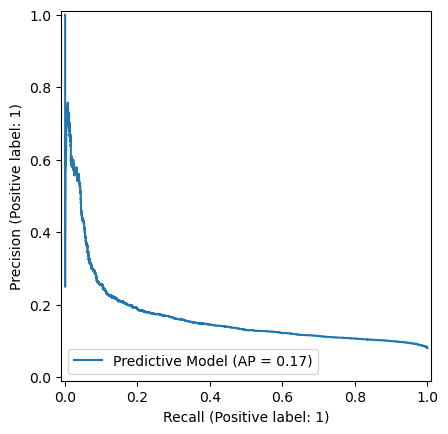

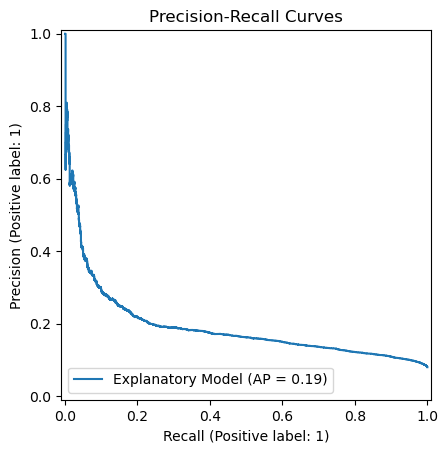

In [236]:
#Ambas curavs juntas
PrecisionRecallDisplay.from_predictions(
    results_predictive['y_test'],
    results_predictive['y_prob'],
    name='Predictive Model'
)

PrecisionRecallDisplay.from_predictions(
    results_explanatory['y_test'],
    results_explanatory['y_prob'],
    name='Explanatory Model'
)

plt.title("Precision-Recall Curves")
plt.show()

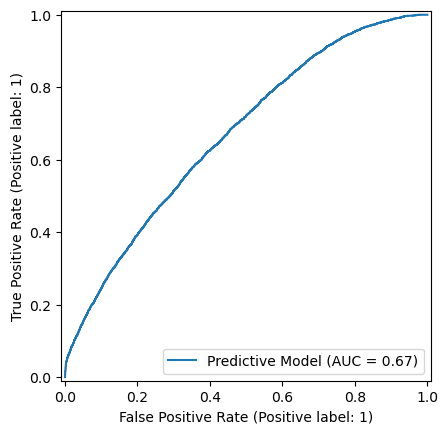

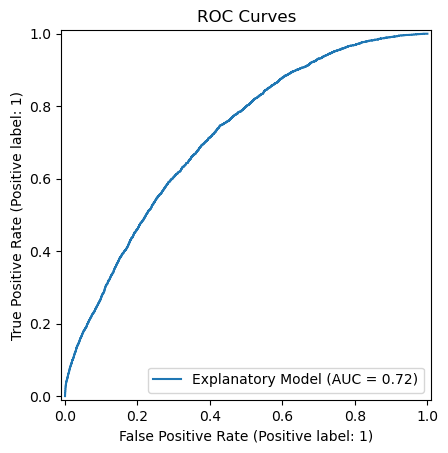

In [237]:
#Curva ROC
RocCurveDisplay.from_predictions(
    results_predictive['y_test'],
    results_predictive['y_prob'],
    name='Predictive Model'
)

RocCurveDisplay.from_predictions(
    results_explanatory['y_test'],
    results_explanatory['y_prob'],
    name='Explanatory Model'
)

plt.title("ROC Curves")
plt.show()


## Modelos sobre el conjunto de variables explicativas

## Tratamiento del desbalanceo: SMOTE

In [238]:
# Hago lo que hice antes de separar y limpiar las variables que iba a usar
#me quedo con cols_drop_common y X_explanatory
#Hago train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_explanatory,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [239]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['Route Type', 'Collision Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Distracted By', 'Vehicle First Impact Location', 'Vehicle Body Type', 'Vehicle Movement', 'Vehicle Going Dir', 'speed_bin', 'vehicle_age_bin']
Numeric: ['Driver At Fault', 'Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'Driver_Substance_Abuse', 'NM_Substance_Abuse', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Crash_Year', 'Vehicle Age', 'circ_driver_behavior', 'circ_traffic_violation', 'circ_maneuver_error', 'circ_loss_control', 'circ_external']


In [240]:
#Creo el preprocesador
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [241]:
#Transformar train y test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [242]:
#ver desbalanceo antes de hacer SMOTE
print("Distribución original en train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

Distribución original en train:
Injured
0    131330
1     11393
Name: count, dtype: int64
Injured
0    92.017404
1     7.982596
Name: proportion, dtype: float64


In [243]:
#Se aplica SMOTE solo al train
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_transformed,
    y_train
)

In [244]:
#Compruebo resultados
print("Distribución después de SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

Distribución después de SMOTE:
Injured
0    131330
1    131330
Name: count, dtype: int64
Injured
0    50.0
1    50.0
Name: proportion, dtype: float64


In [245]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [246]:
#Evaluo el modelo con SMOTE
y_pred_smote = rf_smote.predict(X_test_transformed)
y_prob_smote = rf_smote.predict_proba(X_test_transformed)[:, 1]

print("RANDOM FOREST + SMOTE")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))
print("Average Precision:", average_precision_score(y_test, y_prob_smote))

RANDOM FOREST + SMOTE
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56284
           1       0.22      0.03      0.05      4883

    accuracy                           0.91     61167
   macro avg       0.57      0.51      0.50     61167
weighted avg       0.87      0.91      0.88     61167

ROC-AUC: 0.692290239024049
Average Precision: 0.14993659111178803


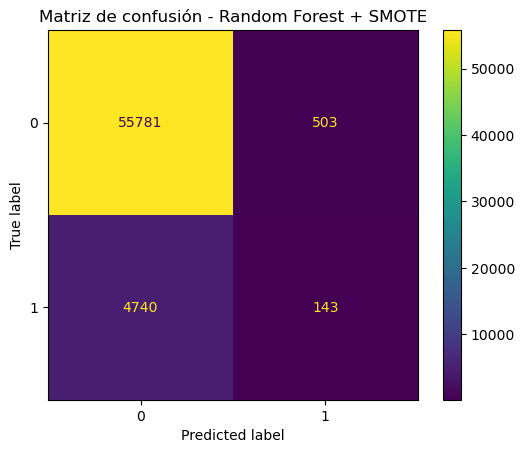

In [247]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote)
disp.plot()
plt.title("Matriz de confusión - Random Forest + SMOTE")
plt.show()

In [248]:
# Pruebo otra técnica

## Balanced Random Forest

In [249]:
#Entreno Balanced Random Forest
balanced_rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        replacement=True
    ))
])

balanced_rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [250]:
#Evaluo el modelo
y_pred_balanced_rf = balanced_rf_model.predict(X_test)
y_prob_balanced_rf = balanced_rf_model.predict_proba(X_test)[:, 1]

print("BALANCED RANDOM FOREST EXP")
print(classification_report(y_test, y_pred_balanced_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced_rf))
print("Average Precision:", average_precision_score(y_test, y_prob_balanced_rf))

BALANCED RANDOM FOREST EXP
              precision    recall  f1-score   support

           0       0.96      0.60      0.74     56284
           1       0.14      0.72      0.23      4883

    accuracy                           0.61     61167
   macro avg       0.55      0.66      0.48     61167
weighted avg       0.90      0.61      0.70     61167

ROC-AUC: 0.7217893265703657
Average Precision: 0.1920051534595775


## Modelos sobre el conjunto de variables predictivas

In [251]:
target = 'Injured'
y = data[target]

# Train-test split estratificado
X_train_pred, X_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_predictive,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Separar variables numéricas y categóricas
categorical_cols_pred = X_train_pred.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_pred = X_train_pred.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print(f"Variables categóricas ({len(categorical_cols_pred)}): {categorical_cols_pred}")
print(f"Variables numéricas ({len(numeric_cols_pred)}): {numeric_cols_pred}")
print(f"\nTrain: {X_train_pred.shape[0]} muestras")
print(f"Test: {X_test_pred.shape[0]} muestras")
print(f"\nDistribución target (train):")
print(y_train_pred.value_counts(normalize=True))

Variables categóricas (10): ['Route Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Driver Distracted By', 'Vehicle Body Type', 'Vehicle Going Dir', 'speed_bin', 'vehicle_age_bin']
Variables numéricas (19): ['Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'Driver_Substance_Abuse', 'NM_Substance_Abuse', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Crash_Year', 'Vehicle Age', 'circ_driver_behavior', 'circ_traffic_violation', 'circ_maneuver_error', 'circ_loss_control', 'circ_external']

Train: 142723 muestras
Test: 61167 muestras

Distribución target (train):
Injured
0    0.920174
1    0.079826
Name: proportion, dtype: float64


In [252]:
# Preprocesador (igual que antes pero con variables predictivas)
numeric_transformer_pred = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_pred = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_pred = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pred, numeric_cols_pred),
        ('cat', categorical_transformer_pred, categorical_cols_pred)
    ]
)

## SMOTE + random forest

In [253]:
# SMOTE + RANDOM FOREST (PREDICTIVO)

# Primero transformamos los datos
X_train_pred_transformed = preprocessor_pred.fit_transform(X_train_pred)
X_test_pred_transformed = preprocessor_pred.transform(X_test_pred)

# Aplicar SMOTE solo al train
smote = SMOTE(random_state=42)
X_train_smote_pred, y_train_smote_pred = smote.fit_resample(
    X_train_pred_transformed,
    y_train_pred
)

print("Distribución después de SMOTE (train):")
print(pd.Series(y_train_smote_pred).value_counts())
print(pd.Series(y_train_smote_pred).value_counts(normalize=True) * 100)

# Entrenar Random Forest sobre datos con SMOTE
rf_smote_pred = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_smote_pred.fit(X_train_smote_pred, y_train_smote_pred)

# Evaluar
y_pred_smote_pred = rf_smote_pred.predict(X_test_pred_transformed)
y_prob_smote_pred = rf_smote_pred.predict_proba(X_test_pred_transformed)[:, 1]

print("\n" + "=" * 60)
print("RANDOM FOREST + SMOTE (VARIABLES PREDICTIVAS)")
print("=" * 60)
print(classification_report(y_test_pred, y_pred_smote_pred))
print(f"ROC-AUC: {roc_auc_score(y_test_pred, y_prob_smote_pred):.4f}")
print(f"Average Precision: {average_precision_score(y_test_pred, y_prob_smote_pred):.4f}")

Distribución después de SMOTE (train):
Injured
0    131330
1    131330
Name: count, dtype: int64
Injured
0    50.0
1    50.0
Name: proportion, dtype: float64

RANDOM FOREST + SMOTE (VARIABLES PREDICTIVAS)
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56284
           1       0.43      0.01      0.03      4883

    accuracy                           0.92     61167
   macro avg       0.68      0.51      0.49     61167
weighted avg       0.88      0.92      0.88     61167

ROC-AUC: 0.6356
Average Precision: 0.1319


## BALANCED RANDOM FOREST (predictivo)

In [254]:
# BALANCED RANDOM FOREST (PREDICTIVO)

balanced_rf_pred = Pipeline(steps=[
    ('preprocessor', preprocessor_pred),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        replacement=True
    ))
])

balanced_rf_pred.fit(X_train_pred, y_train_pred)

# Evaluar
y_pred_brf_pred = balanced_rf_pred.predict(X_test_pred)
y_prob_brf_pred = balanced_rf_pred.predict_proba(X_test_pred)[:, 1]

print("=" * 60)
print("BALANCED RANDOM FOREST (VARIABLES PREDICTIVAS)")
print("=" * 60)
print(classification_report(y_test_pred, y_pred_brf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test_pred, y_prob_brf_pred):.4f}")
print(f"Average Precision: {average_precision_score(y_test_pred, y_prob_brf_pred):.4f}")

BALANCED RANDOM FOREST (VARIABLES PREDICTIVAS)
              precision    recall  f1-score   support

           0       0.95      0.51      0.67     56284
           1       0.11      0.72      0.20      4883

    accuracy                           0.53     61167
   macro avg       0.53      0.61      0.43     61167
weighted avg       0.89      0.53      0.63     61167

ROC-AUC: 0.6721
Average Precision: 0.1645


## TABLA COMPARATIVA

In [255]:
# === TABLA COMPARATIVA FINAL ===

# Métricas del RF predictivo baseline (ya lo tienes, copio tus valores)
# Ajusta estos valores si son diferentes en tu notebook:
results_rf_pred_baseline = {
    'precision_1': precision_score(y_test_pred, balanced_rf_pred.predict(X_test_pred)),  
    'recall_1': recall_score(y_test_pred, balanced_rf_pred.predict(X_test_pred)),
    'f1_1': f1_score(y_test_pred, balanced_rf_pred.predict(X_test_pred)),
}

# Recopilar todo
comparison = pd.DataFrame({
    'Modelo': [
        'RF Predictivo (baseline)',
        'RF Explicativo (referencia)',
        'RF + SMOTE (predictivo)',
        'Balanced RF (predictivo)'
    ],
    'Precision_clase_1': [
        0.115,  # Tu valor del RF predictivo baseline
        0.157,  # Tu valor del RF explicativo
        precision_score(y_test_pred, y_pred_smote_pred),
        precision_score(y_test_pred, y_pred_brf_pred)
    ],
    'Recall_clase_1': [
        0.681,
        0.763,
        recall_score(y_test_pred, y_pred_smote_pred),
        recall_score(y_test_pred, y_pred_brf_pred)
    ],
    'F1_clase_1': [
        0.197,
        0.260,
        f1_score(y_test_pred, y_pred_smote_pred),
        f1_score(y_test_pred, y_pred_brf_pred)
    ],
    'ROC_AUC': [
        0.669,
        0.776,
        roc_auc_score(y_test_pred, y_prob_smote_pred),
        roc_auc_score(y_test_pred, y_prob_brf_pred)
    ],
    'Avg_Precision': [
        0.168,
        0.234,
        average_precision_score(y_test_pred, y_prob_smote_pred),
        average_precision_score(y_test_pred, y_prob_brf_pred)
    ]
})

print("=" * 80)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 80)
print(comparison.round(4).to_string(index=False))
print("=" * 80)
print("\nNota: Umbral por defecto (0.5). Variable target: Injured (0=ileso, 1=no ileso)")
print(f"Desbalanceo: {(y==0).mean()*100:.1f}% clase 0, {(y==1).mean()*100:.1f}% clase 1")

TABLA COMPARATIVA DE MODELOS
                     Modelo  Precision_clase_1  Recall_clase_1  F1_clase_1  ROC_AUC  Avg_Precision
   RF Predictivo (baseline)             0.1150          0.6810      0.1970   0.6690         0.1680
RF Explicativo (referencia)             0.1570          0.7630      0.2600   0.7760         0.2340
    RF + SMOTE (predictivo)             0.4342          0.0135      0.0262   0.6356         0.1319
   Balanced RF (predictivo)             0.1129          0.7164      0.1951   0.6721         0.1645

Nota: Umbral por defecto (0.5). Variable target: Injured (0=ileso, 1=no ileso)
Desbalanceo: 92.0% clase 0, 8.0% clase 1


# Ajuste de umbral, ya que por defecto es 0,5

In [256]:
# === AJUSTE DE UMBRAL ===
# Usamos el Balanced RF predictivo (o el que dé mejores resultados dentro de los predictivos)

# Determinar cuál es mejor entre SMOTE y Balanced RF
if roc_auc_score(y_test_pred, y_prob_brf_pred) >= roc_auc_score(y_test_pred, y_prob_smote_pred):
    best_prob = y_prob_brf_pred
    best_name = "Balanced Random Forest (predictivo)"
    print(f"Mejor modelo: {best_name}")
else:
    best_prob = y_prob_smote_pred
    best_name = "RF + SMOTE (predictivo)"
    print(f"Mejor modelo: {best_name}")

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test_pred, best_prob)

# Calcular F1 para cada umbral
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"\nMejor umbral (maximiza F1): {best_threshold:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall: {recalls[best_idx]:.4f}")
print(f"  F1: {f1_scores[best_idx]:.4f}")

# Aplicar umbral ajustado
y_pred_adjusted = (best_prob >= best_threshold).astype(int)

print(f"\n{'=' * 60}")
print(f"RESULTADOS CON UMBRAL AJUSTADO ({best_threshold:.4f})")
print(f"{'=' * 60}")
print(classification_report(y_test_pred, y_pred_adjusted))

Mejor modelo: Balanced Random Forest (predictivo)

Mejor umbral (maximiza F1): 0.5463
  Precision: 0.1437
  Recall: 0.4278
  F1: 0.2151

RESULTADOS CON UMBRAL AJUSTADO (0.5463)
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     56284
           1       0.14      0.43      0.22      4883

    accuracy                           0.75     61167
   macro avg       0.54      0.60      0.53     61167
weighted avg       0.88      0.75      0.80     61167



### Revisión de variables

In [257]:
# === REVISIÓN DE VARIABLES CATEGÓRICAS ===
# Agrupar categorías poco frecuentes en "OTHER"

print("ANÁLISIS DE CATEGORÍAS POCO FRECUENTES")
print("=" * 60)

threshold_pct = 0.01  # categorías con menos del 1% de observaciones

for col in categorical_cols_pred:
    value_counts = X_predictive[col].value_counts(normalize=True)
    rare_categories = value_counts[value_counts < threshold_pct].index.tolist()
    if rare_categories:
        n_rare = len(rare_categories)
        pct_rare = value_counts[value_counts < threshold_pct].sum() * 100
        print(f"\n{col}:")
        print(f"  Total categorías: {len(value_counts)}")
        print(f"  Categorías raras (<1%): {n_rare}")
        print(f"  % datos en categorías raras: {pct_rare:.2f}%")
        if n_rare <= 10:
            print(f"  Categorías raras: {rare_categories}")

ANÁLISIS DE CATEGORÍAS POCO FRECUENTES

Weather:
  Total categorías: 8
  Categorías raras (<1%): 3
  % datos en categorías raras: 0.64%
  Categorías raras: ['FOG', 'OTHER', 'WIND']

Surface Condition:
  Total categorías: 5
  Categorías raras (<1%): 1
  % datos en categorías raras: 0.15%
  Categorías raras: ['OTHER']

Light:
  Total categorías: 8
  Categorías raras (<1%): 2
  % datos en categorías raras: 1.08%
  Categorías raras: ['DARK_UNKNOWN', 'OTHER']

Traffic Control:
  Total categorías: 11
  Categorías raras (<1%): 6
  % datos en categorías raras: 1.45%
  Categorías raras: ['YIELD_SIGN', 'PERSON_CONTROL', 'PEDESTRIAN', 'WARNING_SIGN', 'RAILROAD', 'SCHOOL_ZONE']

Driver Distracted By:
  Total categorías: 9
  Categorías raras (<1%): 5
  % datos en categorías raras: 1.50%
  Categorías raras: ['EXTERNAL_DISTRACTION', 'CELL_PHONE', 'VEHICLE_CONTROL', 'PASSENGER_DISTRACTION', 'EATING_DRINKING']

Vehicle Body Type:
  Total categorías: 11
  Categorías raras (<1%): 3
  % datos en categoría

In [258]:
#el cambio sería minimo asi que no merece la pena

In [259]:
# Revisar variables binarias con poca varianza
print("\nVARIABLES BINARIAS CON POCA VARIANZA:")
for col in numeric_cols_pred:
    if X_predictive[col].nunique() <= 2:
        pct_ones = X_predictive[col].mean() * 100
        if pct_ones < 1 or pct_ones > 99:
            print(f"  {col}: {pct_ones:.2f}% de unos → CANDIDATA A ELIMINAR")


VARIABLES BINARIAS CON POCA VARIANZA:
  NM_Substance_Abuse: 0.12% de unos → CANDIDATA A ELIMINAR
  circ_driver_behavior: 0.99% de unos → CANDIDATA A ELIMINAR
  circ_maneuver_error: 0.60% de unos → CANDIDATA A ELIMINAR
  circ_loss_control: 0.37% de unos → CANDIDATA A ELIMINAR


## Modelo con variables depuradas

In [260]:
cols_leakage = [
    'Driver Distracted By',
    'Driver_Substance_Abuse',
    'NM_Substance_Abuse',
    'circ_driver_behavior',
    'circ_traffic_violation',
    'circ_maneuver_error',
    'circ_loss_control',
    'circ_external'
]

# Modelo predictivo "limpio" (sin data leakage)
X_predictive_final = X_predictive.drop(columns=cols_leakage, errors='ignore')

print(f"Variables antes: {X_predictive.shape[1]}")
print(f"Variables después: {X_predictive_final.shape[1]}")
print(f"\nVariables finales:")
print(X_predictive_final.columns.tolist())

Variables antes: 29
Variables después: 21

Variables finales:
['Route Type', 'Weather', 'Surface Condition', 'Light', 'Traffic Control', 'Vehicle Body Type', 'Vehicle Going Dir', 'Speed Limit', 'Parked Vehicle', 'Latitude', 'Longitude', 'NonMotorist_Involved', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'month', 'Crash_Year', 'Vehicle Age', 'speed_bin', 'vehicle_age_bin']


### Entrenamiento del Balanced Random Forest Final

In [261]:
# Train/test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_predictive_final, y, test_size=0.3, random_state=42, stratify=y
)

categorical_cols_f = X_train_f.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_f = X_train_f.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# Preprocesador
preprocessor_f = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols_f),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_f)
])

# Modelo
balanced_rf_final = Pipeline(steps=[
    ('preprocessor', preprocessor_f),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1, replacement=True
    ))
])

balanced_rf_final.fit(X_train_f, y_train_f)

y_pred_f = balanced_rf_final.predict(X_test_f)
y_prob_f = balanced_rf_final.predict_proba(X_test_f)[:, 1]

print("\n" + "=" * 60)
print("BALANCED RANDOM FOREST FINAL (sin data leakage) - Umbral 0.5")
print("=" * 60)
print(classification_report(y_test_f, y_pred_f))
print(f"ROC-AUC: {roc_auc_score(y_test_f, y_prob_f):.4f}")
print(f"Average Precision: {average_precision_score(y_test_f, y_prob_f):.4f}")


BALANCED RANDOM FOREST FINAL (sin data leakage) - Umbral 0.5
              precision    recall  f1-score   support

           0       0.95      0.50      0.66     56284
           1       0.11      0.72      0.19      4883

    accuracy                           0.52     61167
   macro avg       0.53      0.61      0.43     61167
weighted avg       0.89      0.52      0.62     61167

ROC-AUC: 0.6667
Average Precision: 0.1592


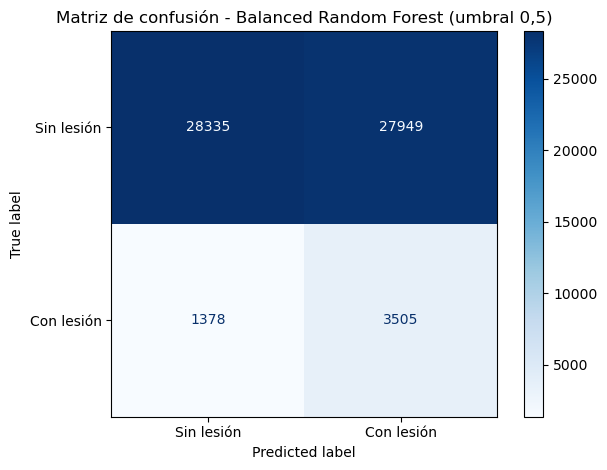

In [262]:
# Matriz de confusión del modelo final (umbral por defecto 0,5)
cm = confusion_matrix(y_test_f, y_pred_f)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin lesión', 'Con lesión']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Balanced Random Forest (umbral 0,5)')
plt.tight_layout()
plt.savefig('matriz_confusion_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [263]:
#AJUSTE DE UMBRAL (sobre el modelo final ya entrenado) ===
precisions, recalls, thresholds = precision_recall_curve(y_test_f, y_prob_f)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = f1_scores.argmax()
best_threshold_f = thresholds[best_idx]

print(f"Mejor umbral (maximiza F1): {best_threshold_f:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall: {recalls[best_idx]:.4f}")
print(f"  F1: {f1_scores[best_idx]:.4f}")

y_pred_adjusted_f = (y_prob_f >= best_threshold_f).astype(int)

print(f"\n{'=' * 60}")
print(f"RESULTADOS CON UMBRAL AJUSTADO ({best_threshold_f:.4f})")
print(f"{'=' * 60}")
print(classification_report(y_test_f, y_pred_adjusted_f))

# Comparación umbral 0.5 vs ajustado
print("Comparación (clase 1):")
print(f"{'Métrica':<12}{'Umbral 0.5':<14}{'Ajustado':<12}")
print(f"{'Precision':<12}{precision_score(y_test_f, y_pred_f):<14.4f}{precision_score(y_test_f, y_pred_adjusted_f):<12.4f}")
print(f"{'Recall':<12}{recall_score(y_test_f, y_pred_f):<14.4f}{recall_score(y_test_f, y_pred_adjusted_f):<12.4f}")
print(f"{'F1':<12}{f1_score(y_test_f, y_pred_f):<14.4f}{f1_score(y_test_f, y_pred_adjusted_f):<12.4f}")

Mejor umbral (maximiza F1): 0.5466
  Precision: 0.1409
  Recall: 0.4180
  F1: 0.2107

RESULTADOS CON UMBRAL AJUSTADO (0.5466)
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     56284
           1       0.14      0.42      0.21      4883

    accuracy                           0.75     61167
   macro avg       0.54      0.60      0.53     61167
weighted avg       0.88      0.75      0.80     61167

Comparación (clase 1):
Métrica     Umbral 0.5    Ajustado    
Precision   0.1114        0.1409      
Recall      0.7178        0.4180      
F1          0.1929        0.2107      


## Análisis SHAP

In [264]:
#Primero me aseguro que vuelvo a cargar bien el modelo explicativo, ya que he vuelto a usar mismas variables y se pueden superponer

In [265]:
# === MODELO EXPLICATIVO PARA SHAP ===
# (incluye todas las variables, también las post-accidente)

# Train/test split con variables explicativas
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_explanatory, y, test_size=0.3, random_state=42, stratify=y
)

categorical_cols_e = X_train_e.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_e = X_train_e.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

preprocessor_e = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols_e),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols_e)
])

balanced_rf_explan = Pipeline(steps=[
    ('preprocessor', preprocessor_e),
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1, replacement=True
    ))
])

balanced_rf_explan.fit(X_train_e, y_train_e)

y_prob_e = balanced_rf_explan.predict_proba(X_test_e)[:, 1]
print("BALANCED RF EXPLICATIVO")
print(classification_report(y_test_e, balanced_rf_explan.predict(X_test_e)))
print(f"ROC-AUC: {roc_auc_score(y_test_e, y_prob_e):.4f}")
print(f"Average Precision: {average_precision_score(y_test_e, y_prob_e):.4f}")

BALANCED RF EXPLICATIVO
              precision    recall  f1-score   support

           0       0.96      0.60      0.74     56284
           1       0.14      0.72      0.23      4883

    accuracy                           0.61     61167
   macro avg       0.55      0.66      0.48     61167
weighted avg       0.90      0.61      0.70     61167

ROC-AUC: 0.7218
Average Precision: 0.1920


In [266]:
# Cálculo de los valores SHAP

# Extraer el preprocesador y el clasificador entrenados
fitted_preprocessor_e = balanced_rf_explan.named_steps['preprocessor']
fitted_classifier_e = balanced_rf_explan.named_steps['classifier']

# Transformar X_test
X_test_transformed_e = fitted_preprocessor_e.transform(X_test_e)
feature_names_e = fitted_preprocessor_e.get_feature_names_out()

# Convertir a DataFrame
X_test_df_e = pd.DataFrame(
    X_test_transformed_e.toarray() if hasattr(X_test_transformed_e, "toarray") else X_test_transformed_e,
    columns=feature_names_e
)

# Muestra de 1000 observaciones para que no tarde demasiado
sample_size = min(1000, len(X_test_df_e))
X_shap_e = X_test_df_e.sample(sample_size, random_state=42)

# Calcular SHAP values con TreeExplainer
explainer_e = shap.TreeExplainer(fitted_classifier_e)
shap_values_e = explainer_e.shap_values(X_shap_e)

print(f"Shape de shap_values: {np.array(shap_values_e).shape}")
print("SHAP calculado correctamente")

Shape de shap_values: (1000, 137, 2)
SHAP calculado correctamente


In [267]:
# AGREGACIÓN DE SHAP POR VARIABLE ORIGINAL
# Resuelve el problema del one-hot que fragmenta cada variable categórica

# Seleccionar los SHAP values de la clase 1 (no ileso)
shap_arr = np.array(shap_values_e)
if shap_arr.ndim == 3:           # (muestras, features, clases)
    shap_class_1 = shap_arr[:, :, 1]
elif isinstance(shap_values_e, list):
    shap_class_1 = np.array(shap_values_e[1])
else:
    shap_class_1 = shap_arr

# Función para mapear cada feature transformada a su variable original
def get_original_var(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    elif feature_name.startswith("cat__"):
        rest = feature_name.replace("cat__", "")
        # Buscar a qué columna categórica original pertenece
        for col in categorical_cols_e:
            if rest.startswith(col + "_") or rest == col:
                return col
        return rest
    return feature_name

original_var_names = [get_original_var(f) for f in feature_names_e]

# DataFrame con valores absolutos de SHAP, agrupado por variable original
shap_abs_df = pd.DataFrame(np.abs(shap_class_1), columns=original_var_names)
shap_grouped = shap_abs_df.T.groupby(level=0).sum().T

# Importancia media por variable original
mean_shap_importance = shap_grouped.mean().sort_values(ascending=False)

print("=" * 60)
print("IMPORTANCIA DE VARIABLES (SHAP agregado por variable original)")
print("=" * 60)
print(mean_shap_importance.head(15))

IMPORTANCIA DE VARIABLES (SHAP agregado por variable original)
Collision Type                   0.057278
Vehicle Body Type                0.038221
Vehicle Movement                 0.037632
Vehicle First Impact Location    0.018765
speed_bin                        0.015515
Speed Limit                      0.013560
Driver At Fault                  0.012030
Route Type                       0.010251
Crash_Year                       0.010125
Latitude                         0.009507
Surface Condition                0.009473
Driver Distracted By             0.007153
Traffic Control                  0.005079
NonMotorist_Involved             0.004883
Longitude                        0.004236
dtype: float64


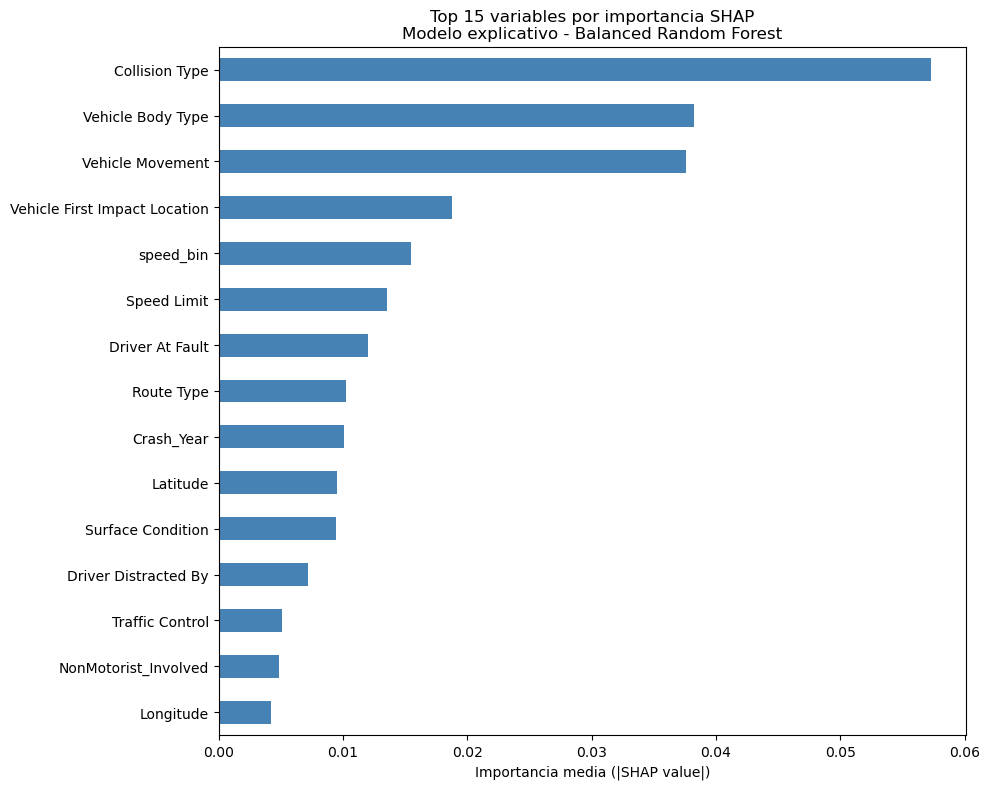

In [268]:
# Gráfico de importancia SHAP
fig, ax = plt.subplots(figsize=(10, 8))
mean_shap_importance.head(15).sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_xlabel('Importancia media (|SHAP value|)')
ax.set_title('Top 15 variables por importancia SHAP\n'
             'Modelo explicativo - Balanced Random Forest')
plt.tight_layout()
plt.savefig('shap_importancia_explicativo.png', dpi=150, bbox_inches='tight')
plt.show()

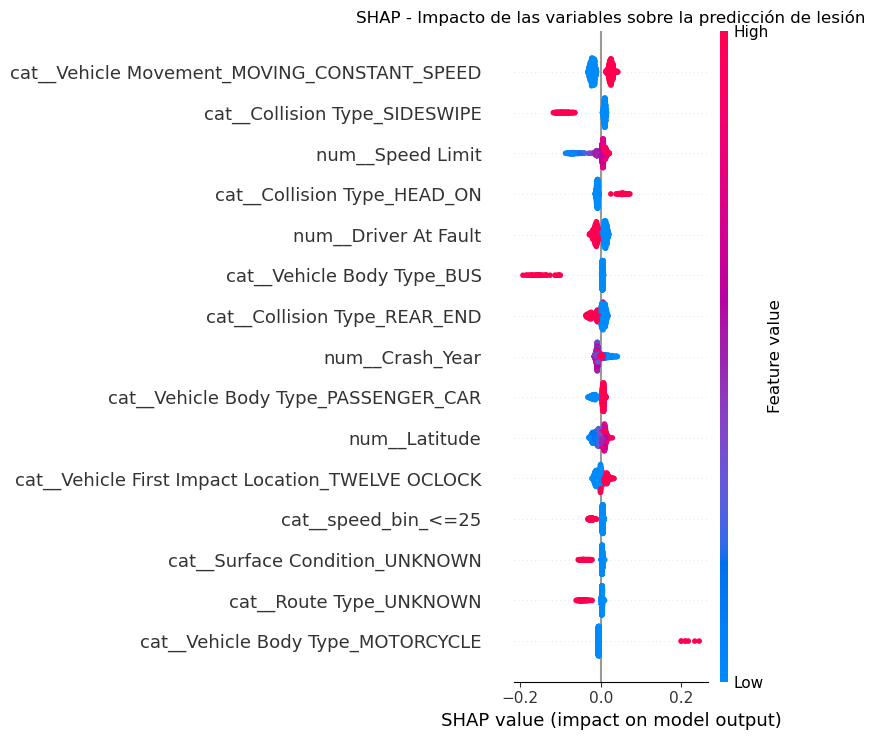

In [269]:
#Gráfico beeswarm
shap.summary_plot(
    shap_class_1,
    X_shap_e,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.title("SHAP - Impacto de las variables sobre la predicción de lesión")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [270]:
data.shape

(203890, 63)

In [271]:
data.columns.tolist()

['Agency Name',
 'Route Type',
 'Road Name',
 'Collision Type',
 'Weather',
 'Surface Condition',
 'Light',
 'Traffic Control',
 'Driver At Fault',
 'Driver Distracted By',
 'Drivers License State',
 'Vehicle Damage Extent',
 'Vehicle First Impact Location',
 'Vehicle Body Type',
 'Vehicle Movement',
 'Vehicle Going Dir',
 'Speed Limit',
 'Parked Vehicle',
 'Vehicle Make',
 'Latitude',
 'Longitude',
 'NonMotorist_Involved',
 'Driver_Substance_Abuse',
 'NM_Substance_Abuse',
 'hour',
 'day_of_week',
 'is_weekend',
 'is_night',
 'month',
 'Road_Top',
 'Top_Cross_Street',
 'Crash_Year',
 'Vehicle Age',
 'circ_speeding',
 'circ_inattentive',
 'circ_followed_too_closely',
 'circ_failed_yield',
 'circ_ran_red_light',
 'circ_ran_stop_sign',
 'circ_improper_turn',
 'circ_improper_passing',
 'circ_improper_backing',
 'circ_reckless',
 'circ_lane_violation',
 'circ_ran_off_roadway',
 'circ_wrong_way',
 'circ_wrong_side',
 'circ_overcorrecting',
 'circ_vision_obstruction',
 'circ_animal',
 'circ_d